# Project Nine Mens's Morris



**Runtime:** ~30 minutes for baseline

## Setup

In [ ]:
!pip install numpy matplotlib gymnasium
!pip install sb3-contrib stable-baselines3
!pip install tensorboard
!pip install ray
!pip install dm-tree

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import random
import gymnasium as gym
import torch

from dataclasses import dataclass
from gymnasium import spaces
from sb3_contrib.common.wrappers import ActionMasker
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib import MaskablePPO
from IPython.display import display, HTML
from collections import defaultdict

torch.distributions.Distribution.set_default_validate_args(False)
from gymnasium.spaces import Dict, Box
from datetime import datetime
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.logger import configure
from stable_baselines3.common.callbacks import CallbackList

In [4]:
log_dir = "./logs/mill_ppo/"
os.makedirs(log_dir, exist_ok=True)
csv_path = os.path.join(log_dir, "progress.csv")
device = "mps" if torch.backends.mps.is_available() else "cpu"

*If USE_SHAPING = False the sparse model will be trained. The model is only rewarded for winning (+10).*


*If USE_SHAPING = True, the potential based reward model will be trained. The model is rewarded also for capture (+ 0.05), building a mill (+ 0.1) and illegal move (-0.1)*

In [5]:
USE_SHAPING = False

In [6]:
# Create 24 positions
# all moves allowed on different positions

ADJ = {
    0:[1,9], 1:[0,2,4], 2:[1,14],
    3:[4,10], 4:[1,3,5,7], 5:[4,13],
    6:[7,11], 7:[4,6,8], 8:[7,12],
    9:[0,10,21], 10:[3,9,11,18], 11:[6,10,15],
    12:[8,13,17], 13:[5,12,14,20], 14:[2,13,23],
    15:[11,16], 16:[15,17,19], 17:[12,16],
    18:[10,19], 19:[16,18,20,22], 20:[13,19],
    21:[9,22], 22:[19,21,23], 23:[14,22]
}

# all possible mills
MILLS = [
    (0,1,2),(3,4,5),(6,7,8),
    (9,10,11),(12,13,14),(15,16,17),
    (18,19,20),(21,22,23),
    (0,9,21),(3,10,18),(6,11,15),
    (1,4,7),(16,19,22),(8,12,17),
    (5,13,20),(2,14,23),
]

# is stone part of a mill?
def is_mill(board, pos, player):
    "True, wenn pos Teil einer geschlossenen Mühle von player ist."
    for a,b,c in MILLS:
        if pos in (a,b,c) and board[a]==board[b]==board[c]==player:
            return True
    return False

def mills_formed_by_move(board_before, board_after, player):
    "Welche Mühlen sind neu geschlossen?"
    formed=[]
    for a,b,c in MILLS:
        before = (board_before[a]==board_before[b]==board_before[c]==player)
        after  = (board_after[a]==board_after[b]==board_after[c]==player)
        if (not before) and after:
            formed.append((a,b,c))
    return formed

def removable_positions(board, opponent):
    "Welche gegnerischen Steine dürfen entfernt werden?"
    opp_pos = [i for i,v in enumerate(board) if v==opponent]
    # Steine in Mühlen sind geschützt, außer alle sind in Mühlen
    non_mill = [i for i in opp_pos if not is_mill(board, i, opponent)]
    return non_mill if len(non_mill)>0 else opp_pos

# Directed edge list for move actions: A stone may be moved from field u to field v.
EDGE_DIR = [(u,v) for u,vs in ADJ.items() for v in vs] # possible actions
E = len(EDGE_DIR) # How many possible actions are there?
E

64

## Action Encoding

In [7]:
# Action Encoding
# - Place:   0..23
# - Move:    24 .. 24+E-1  (EDGE_DIR index)
# - Fly:     24+E .. 24+E+24*24-1  (src*24 + dst)
# - Capture:  (end) .. +23

PLACE_N = 24
MOVE_OFFSET = PLACE_N
FLY_OFFSET = PLACE_N + E
CAPTURE_OFFSET = FLY_OFFSET + 24*24
N_ACTIONS = CAPTURE_OFFSET + 24

def encode_place(pos): 
    return pos

def encode_move(edge_idx):
    return MOVE_OFFSET + edge_idx

def encode_fly(src,dst):
    return FLY_OFFSET + src*24 + dst

def decode_action(a):
    if a < PLACE_N:
        return ("place", a)

    if a < FLY_OFFSET:
        idx = a - MOVE_OFFSET
        return ("move", EDGE_DIR[idx])

    if a < CAPTURE_OFFSET:
        idx = a - FLY_OFFSET
        src, dst = divmod(idx, 24)
        return ("fly", (src, dst))

    pos = a - CAPTURE_OFFSET
    return ("capture", pos)
    
def encode_capture(pos):
    return CAPTURE_OFFSET + pos

N_ACTIONS

688

## Skeleton

In [14]:
@dataclass
class MillState:
    """
    Lightweight container for the full game state of Nine Men's Morris.
    """
    
    board: np.ndarray              # shape (24,), values {-1,0,1} from perspective (player1=+1, player2=-1)
    player: int                    # +1 or -1 whose turn
    to_place_p1: int               # how many stones are left
    to_place_p2: int
    need_capture: bool             # remove stone after building a mill
    phase: int                     # 0=placement, 1=move, 2=fly
    turn_count: int
    no_capture_count: int          # counter since last mill

class MillEnv(gym.Env):
    """
    Gymnasium environment for Nine Men's Morris with action masking and optional PBRS.

    Overview
    --------
    - Observation: current-player perspective board (24) + 5 normalized meta features
      (phase, stones-to-place self/opp, need_capture, no_capture_count).
    - Actions: discrete action space with encoded segments (place/move/fly/capture).
    - Legal moves are exposed via action_mask() for sb3-contrib MaskablePPO.

    Rewards
    -------
    Base reward (always active):
      - Win:  +10, Loss: -10 (terminal)
      - Draw by no-capture limit: 0 (truncated)
      - Illegal action: -1 (non-terminal penalty)
      - Capture: +0.05, Form a mill (enables capture): +0.1

    Optional Potential-Based Reward Shaping (PBRS):
      Enabled with use_shaping=True.
      Adds: r_shaping = shaping_gamma * Phi(s') - Phi(s)
      where Phi(s) is computed from:
        - material difference (Δmat)
        - closed mills difference (Δmills)
        - open mills difference (Δopenmills)

    Termination / Truncation
    ------------------------
    - term_pieces: after placement, if a player has < 3 stones (loss).
    - term_block: after placement, if the next player has no legal moves (win).
    - term_illegal: illegal action attempted (penalized; game continues by design).
    - term_nocap: no_capture_count >= max_no_capture (draw / truncation).
    """
    
    metadata = {"render_modes": ["ansi"], "render_fps": 4}

    def __init__(
        self, max_no_capture=50, render_mode=None,
        use_shaping=False, shaping_gamma=0.99,
        w_mat=1.0, w_mills=0.7, w_open=0.4,
        clip_phi=10.0
    ):
        
        super().__init__()
        self.max_no_capture = max_no_capture
        self.render_mode = render_mode
        self.use_shaping = bool(use_shaping)
        self.shaping_gamma = float(shaping_gamma)
        self.w_mat = float(w_mat)
        self.w_mills = float(w_mills)
        self.w_open = float(w_open)
        self.clip_phi = float(clip_phi)
        self.win_reward = 10.0
        self.lose_reward = -10.0
        

        # Observation: board(24) + phase + to_place_self + to_place_opp + need_capture + (optional counters)
        # Maximum allowed range of values for all states

        low = np.array([-1.0]*24 + [0.0]*5, dtype=np.float32)
        high = np.array([ 1.0]*24 + [1.0]*5, dtype=np.float32)
        
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)
        self.action_space = spaces.Discrete(N_ACTIONS)
        self.state: MillState|None = None

    # phase of current player 
    def _phase_from_counts(self, st: MillState):
        p1 = np.sum(st.board==1) # how many stones has player 1
        p2 = np.sum(st.board==-1) # how many stones has player 2
        
        if st.to_place_p1>0 or st.to_place_p2>0:
            return 0
            
        # flying rule: player with 3 stones can fly, but phase depends on current player
        stones = p1 if st.player==1 else p2
        return 2 if stones<=3 else 1

    def _obs(self):
        st = self.state
        assert st is not None
        
        # perspective: from current player viewpoint
        board = (st.board * st.player).astype(np.int16)
        
        to_place_self = st.to_place_p1 if st.player==1 else st.to_place_p2 # agent stones
        to_place_opp  = st.to_place_p2 if st.player==1 else st.to_place_p1 # opponent stones
        
        nocap = int(st.no_capture_count)
        if nocap < 0:
            nocap = 0
        if nocap > self.max_no_capture:
            nocap = self.max_no_capture

        meta = np.array([
            st.phase / 2.0,
            to_place_self / 9.0,
            to_place_opp / 9.0,
            1.0 if st.need_capture else 0.0,
            nocap / self.max_no_capture
        ], dtype=np.float32)
        return np.concatenate([board.astype(np.float32), meta])
        

    # new game
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = MillState(
            board=np.zeros(24, dtype=np.int8),
            player=1,
            to_place_p1=9, to_place_p2=9,
            need_capture=False,
            phase=0,
            turn_count=0,
            no_capture_count=0
        )
        return self._obs(), {"action_mask": self.action_mask()} 

    
    # phase gating: select action segment (place/move/fly/capture)
    # legality-Gating: filters only the legal moves within the segment   
    def action_mask(self):
        st = self.state
        assert st is not None
        mask = np.zeros(N_ACTIONS, dtype=np.bool_)
        player = st.player
        opp = -player
    
        # capture-only mode
        if st.need_capture:
            for pos in removable_positions(st.board, opp):
                mask[encode_capture(pos)] = True
            return mask   # ✅ muss hier drin sein
    
        # placement
        if st.phase == 0:
            for pos in range(24):
                if st.board[pos] == 0:
                    mask[encode_place(pos)] = True
            return mask
    
        own_positions   = [i for i, v in enumerate(st.board) if v == player]
        empty_positions = [i for i, v in enumerate(st.board) if v == 0]
    
        # move along edges
        if st.phase == 1:
            for ei, (u, v) in enumerate(EDGE_DIR):
                if st.board[u] == player and st.board[v] == 0:
                    mask[encode_move(ei)] = True
            return mask
    
        # fly anywhere
        for src in own_positions:
            for dst in empty_positions:
                mask[encode_fly(src, dst)] = True
        return mask

    def step(self, action):
        st = self.state
        assert st is not None
    
        terminated = False
        truncated = False
        reward = 0.0 
        reward_sparse = 0.0
        terminal_reason = None # 0 none, 1 pieces, 2 block, 3 no_capture, 4 illegal
        winner = 0           # +1 p1, -1 p2, 0 draw/none
        did_capture = 0
        formed_mill = 0
    
        mask = self.action_mask()
        if not mask[action]:
            reward = -1.0
            terminated = False
            terminal_reason = "term_illegal"  # illegal
            truncated = False
            winner = -st.player
    
            info = {
                "illegal": True,
                "legal_actions": int(mask.sum()),
                "need_capture": int(st.need_capture),
                "phase": int(st.phase),
                "turn": int(st.turn_count),
                "terminal_reason": terminal_reason,
                "winner": winner,
                "did_capture": int(did_capture),
                "formed_mill": int(formed_mill),
                "action_mask": mask,
            }
            return self._obs(), reward, terminated, truncated, info
    
        acting_player = st.player
        phi_before = 0.0
        if self.use_shaping:
            phi_before = self._phi(st.board, acting_player)
                
        kind, payload = decode_action(action)  
        did_capture_int = int(kind == "capture")
    
        if kind == "capture":
            did_capture = 1 
            pos = payload
            st.board[pos] = 0
            st.need_capture = False
            st.no_capture_count = 0
            reward += 0.05
        else:
            board_before = st.board.copy()
    
            if kind == "place":
                pos = payload
                st.board[pos] = st.player
                if st.player == 1:
                    st.to_place_p1 -= 1
                else:
                    st.to_place_p2 -= 1
    
            elif kind == "move":
                src, dst = payload
                st.board[src] = 0
                st.board[dst] = st.player
    
            elif kind == "fly":
                src, dst = payload
                st.board[src] = 0
                st.board[dst] = st.player
    
            formed = mills_formed_by_move(board_before, st.board, st.player)
            formed_mill = 1 if len(formed) > 0 else 0

            opp = -st.player
            opp_on_board = int(np.sum(st.board == opp))
    
            if formed_mill and opp_on_board > 0:
                st.need_capture = True
                st.no_capture_count = 0
                reward += 0.1
                assert np.any(st.board == opp), \
                    "need_capture=True but no opponent stones on board"
            else:
                st.need_capture = False
                st.no_capture_count += 1
    
        st.turn_count += 1
        st.phase = self._phase_from_counts(st)
    
        placement_over = (st.to_place_p1 == 0 and st.to_place_p2 == 0)
    
        if placement_over and (kind == "capture"):
            p1 = int(np.sum(st.board == 1))
            p2 = int(np.sum(st.board == -1))
    
            if p1 < 3 or p2 < 3:
                terminated = True
                terminal_reason = "term_pieces"
                winner = 1 if p1 > p2 else -1
                reward += self.win_reward if acting_player == winner else self.lose_reward

        if not terminated and st.no_capture_count >= self.max_no_capture:
            truncated = True
            terminal_reason = "term_nocap"
            winner = 0
    
        # switch player only if no capture pending and game not ended
        if (not terminated) and (not truncated) and (not st.need_capture):
            st.player *= -1
            st.phase = self._phase_from_counts(st)
    
        if placement_over and self.action_mask().sum() == 0:
            terminated = True
            terminal_reason = "term_block"
            winner = acting_player
            reward += self.win_reward

        next_mask = self.action_mask()
        
        reward_sparse = float(reward)        
        shaping = 0.0
        
        if self.use_shaping:
            phi_after = self._phi(st.board, acting_player)
            shaping = self.shaping_gamma * phi_after - phi_before
            reward = float(reward) + float(shaping)

        info = {
           "illegal": False,
            "legal_actions": int(next_mask.sum()),
            "need_capture": int(st.need_capture),
            "phase": int(st.phase),
            "turn": int(st.turn_count),
            "terminal_reason": terminal_reason,
            "winner": winner,
            "did_capture": int(did_capture),
            "formed_mill": int(formed_mill),
            "action_mask": next_mask,
            "reward_sparse": float(reward_sparse),
            "reward_shaping": float(shaping),
            "reward_total": float(reward),
        }    
   
        return self._obs(), reward, terminated, truncated, info

    def _phi(self, board: np.ndarray, player: int) -> float:
        """Potential Φ(s) aus Sicht von 'player' (+1 oder -1)."""
        me = int(player)
        opp = -me
    
        mat_me = int(np.sum(board == me))
        mat_opp = int(np.sum(board == opp))
        d_mat = mat_me - mat_opp
    
        mills_me = 0
        mills_opp = 0
        for a, b, c in MILLS:
            if board[a] == board[b] == board[c] == me:
                mills_me += 1
            elif board[a] == board[b] == board[c] == opp:
                mills_opp += 1
        d_mills = mills_me - mills_opp
    
        open_me = 0
        open_opp = 0
        for a, b, c in MILLS:
            line = (board[a], board[b], board[c])
            if line.count(me) == 2 and line.count(0) == 1:
                open_me += 1
            if line.count(opp) == 2 and line.count(0) == 1:
                open_opp += 1
        d_open = open_me - open_opp
    
        phi = (
            self.w_mat * d_mat
            + self.w_mills * d_mills
            + self.w_open * d_open
        )
    
        if self.clip_phi is not None:
            phi = float(np.clip(phi, -self.clip_phi, self.clip_phi))
    
        return float(phi)

    def render(self):
        # Für Start: nur kurzer Text
        st = self.state
        assert st is not None
        return (
            f"player={st.player}, "
            f"phase={st.phase}, "
            f"to_place=({st.to_place_p1},{st.to_place_p2}), "
            f"need_capture={st.need_capture}\nboard={st.board}"
        )


## Integration test baseline

In [15]:
env = MillEnv(use_shaping=USE_SHAPING,)
obs, info = env.reset()
print("phase:", env.state.phase, "need_capture:", env.state.need_capture)
print("mask sum:", info["action_mask"].sum())
print("first 30 mask:", np.flatnonzero(info["action_mask"])[:30])
print("board:", env.state.board)
print("obs shape:", obs.shape)
print("legal actions:", info["action_mask"].sum())
print("use_shaping: ", USE_SHAPING)

# Run a short random rollout using action masks
rng = np.random.default_rng(0)
obs, info = env.reset()
for t in range(10):
    mask = info["action_mask"]
    legal = np.flatnonzero(mask)
    a = int(rng.choice(legal))
    obs, r, term, trunc, info = env.step(a)
    print(t, decode_action(a), r, term, trunc)
    if term or trunc:
        break
print(env.render())

phase: 0 need_capture: False
mask sum: 24
first 30 mask: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
board: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
obs shape: (29,)
legal actions: 24
use_shaping:  False
0 ('place', 20) 0.0 False False
1 ('place', 14) 0.0 False False
2 ('place', 11) 0.0 False False
3 ('place', 5) 0.0 False False
4 ('place', 7) 0.0 False False
5 ('place', 0) 0.0 False False
6 ('place', 2) 0.0 False False
7 ('place', 1) 0.0 False False
8 ('place', 6) 0.0 False False
9 ('place', 21) 0.0 False False
player=1, phase=0, to_place=(4,4), need_capture=False
board=[-1 -1  1  0  0 -1  1  1  0  0  0  1  0  0 -1  0  0  0  0  0  1 -1  0  0]


## Self play

Single agent reinforcement learning

In [16]:
class MillMetricsCallback(BaseCallback):
    """
    Collects training metrics for the mill environment and optionally runs self-play by
    periodically snapshotting the current policy and sampling opponents from a snapshot pool.
    """

    TERMINAL_REASONS = ("term_pieces", "term_block", "term_nocap", "term_illegal")

    def __init__(
        self,
        verbose=0,
        prefix="rollout",

        # self-play settings (optional)
        enable_selfplay: bool = True,
        snapshot_dir: str = "./logs/mill_selfplay/snapshots",
        snapshot_freq: int = 50_000,
        max_pool_size: int = 10,
        warmup_random_steps: int = 50_000,
        deterministic_opp: bool = True,
        seed: int = 0,
        include_current_as_opponent: bool = True,
        run_id = None,
    ):
        super().__init__(verbose)
        self.prefix = prefix
        if run_id is None:
            self.run_id = datetime.now().strftime("%Y%m%d-%H%M")
        else:
            self.run_id = run_id
            
        # self-play config
        self.enable_selfplay = bool(enable_selfplay)
        self.snapshot_dir = snapshot_dir
        self.snapshot_freq = int(snapshot_freq)
        self.max_pool_size = int(max_pool_size)
        self.warmup_random_steps = int(warmup_random_steps)
        self.deterministic_opp = bool(deterministic_opp)
        self.include_current_as_opponent = bool(include_current_as_opponent)

        self.rng = random.Random(seed)
        self.pool: list[str] = []
        self._next_snapshot_at = self.snapshot_freq
        self._fixed_wrapper = None  # cached reference to FixedOpponentWrapper (unwrapped)

        os.makedirs(self.snapshot_dir, exist_ok=True)

        self._reset_ep()
        self._reset_rollout_counters()

    # episode counters
    def _reset_ep(self):
        self.ep_steps = 0
        self.ep_illegal_steps = 0
        self.ep_need_capture_steps = 0
        self.ep_legal_actions_sum = 0
        self.ep_mills = 0
        self.ep_captures = 0
        self.ep_terminal_reason = None
        self.ep_winner = None

    # rollout counters
    def _reset_rollout_counters(self):
        self.ro_steps = 0
        self.ro_illegal_steps = 0
        self.ro_needcap_steps = 0
        self.ro_legal_actions_sum = 0
        self.ro_mills = 0
        self.ro_captures = 0

        self.ro_episodes_finished = 0
        self.ro_term_counts = {r: 0 for r in self.TERMINAL_REASONS}
        self.ro_term_counts["unknown"] = 0
        self.ro_win_counts = {"p1": 0, "p2": 0, "draw": 0, "unknown": 0}

    def _get_info(self) -> dict:
        infos = self.locals.get("infos", None)
        if infos is None:
            return {}
        if isinstance(infos, (list, tuple)):
            return infos[0] if len(infos) > 0 and isinstance(infos[0], dict) else {}
        return infos if isinstance(infos, dict) else {}

    def _is_done(self) -> bool:
        dones = self.locals.get("dones", None)
        if dones is None:
            return False
        if isinstance(dones, (list, tuple, np.ndarray)):
            return bool(dones[0])
        return bool(dones)

    # self-play helpers
    def _unwrap_to_fixed_opponent(self, env):
        cur = env
        seen = set()
        while cur is not None and id(cur) not in seen:
            seen.add(id(cur))
            if hasattr(cur, "set_opponent"):
                return cur
            cur = getattr(cur, "env", None)
        raise RuntimeError("FixedOpponentWrapper (with set_opponent) not found in wrapper stack.")

    def _load_existing_pool(self):
        paths = sorted(glob.glob(os.path.join(self.snapshot_dir, "snapshot_*.zip")))
        self.pool = paths[-self.max_pool_size :]

    def _trim_pool(self):
        if len(self.pool) > self.max_pool_size:
            self.pool = self.pool[-self.max_pool_size :]

    def _save_snapshot(self) -> str:
        filename = f"snapshot_{self.num_timesteps:010d}_{self.run_id}.zip"
        
        path = os.path.join(self.snapshot_dir, filename)
        self.model.save(path)
        return path

    def _pick_opponent_path(self) -> str | None:
        if not self.pool:
            return None
        return self.rng.choice(self.pool)

    def _set_opponent(self, opponent_model_or_none):
        if self._fixed_wrapper is None:
            base = self.training_env.envs[0] 
            self._fixed_wrapper = self._unwrap_to_fixed_opponent(base)
        self._fixed_wrapper.set_opponent(opponent_model_or_none, deterministic_opp=self.deterministic_opp)

    def _maybe_switch_opponent(self):
        if self.num_timesteps < self.warmup_random_steps or not self.pool:
            self._set_opponent(None)
            if self.verbose:
                print(f"[SelfPlay] t={self.num_timesteps}: opponent=None (warmup/random)")
            return

        opp_path = self._pick_opponent_path()
        if opp_path is None:
            self._set_opponent(None)
            return

        opp = MaskablePPO.load(opp_path, device=device)
        self._set_opponent(opp)
        if self.verbose:
            print(f"[SelfPlay] t={self.num_timesteps}: opponent <- {os.path.basename(opp_path)}")


    def _on_training_start(self) -> None:
        if not self.enable_selfplay:
            return
        self._load_existing_pool()
        self._maybe_switch_opponent()

    def _on_step(self) -> bool:
        info = self._get_info()

        # step counters
        self.ep_steps += 1
        self.ro_steps += 1

        illegal = int(bool(info.get("illegal", False)))
        legal_actions = int(info.get("legal_actions", 0))
        need_capture = int(info.get("need_capture", 0))
        formed_mill = int(info.get("formed_mill", 0))
        did_capture = int(info.get("did_capture", 0))

        # episode
        self.ep_illegal_steps += illegal
        self.ep_legal_actions_sum += legal_actions
        self.ep_need_capture_steps += (1 if need_capture == 1 else 0)
        self.ep_mills += formed_mill
        self.ep_captures += did_capture

        # rollout
        self.ro_illegal_steps += illegal
        self.ro_legal_actions_sum += legal_actions
        self.ro_needcap_steps += (1 if need_capture == 1 else 0)
        self.ro_mills += formed_mill
        self.ro_captures += did_capture

        # capture terminal info
        tr = info.get("terminal_reason", None)
        if tr is not None:
            tr = str(tr)
            if tr in self.TERMINAL_REASONS:
                self.ep_terminal_reason = tr

        w = info.get("winner", None)
        if w is not None:
            try:
                self.ep_winner = int(w)
            except Exception:
                self.ep_winner = None

        if self._is_done():
            steps = max(self.ep_steps, 1)
            p = self.prefix

            self.logger.record(f"{p}/illegalActionRate", float(self.ep_illegal_steps / steps))
            self.logger.record(f"{p}/millsPerEpisode", float(self.ep_mills))
            self.logger.record(f"{p}/capturePerEpisode", float(self.ep_captures))
            self.logger.record(f"{p}/needCaptureFrequency", float(self.ep_need_capture_steps / steps))
            self.logger.record(f"{p}/meanLegalActionCount", float(self.ep_legal_actions_sum / steps))

            final_tr = self.ep_terminal_reason if self.ep_terminal_reason in self.TERMINAL_REASONS else "unknown"
            for r in self.TERMINAL_REASONS:
                self.logger.record(f"{p}/terminalReason_{r}", 1.0 if final_tr == r else 0.0)
            self.logger.record(f"{p}/terminalReason_unknown", 1.0 if final_tr == "unknown" else 0.0)

            ww = self.ep_winner
            self.logger.record(f"{p}/win_p1", 1.0 if ww == 1 else 0.0)
            self.logger.record(f"{p}/win_p2", 1.0 if ww == -1 else 0.0)
            self.logger.record(f"{p}/draw", 1.0 if ww == 0 else 0.0)
            self.logger.record(f"{p}/winner_unknown", 1.0 if ww not in (1, -1, 0) else 0.0)

            # rollout episode-based counters
            self.ro_episodes_finished += 1
            self.ro_term_counts[final_tr] = self.ro_term_counts.get(final_tr, 0) + 1
            if ww == 1:
                self.ro_win_counts["p1"] += 1
            elif ww == -1:
                self.ro_win_counts["p2"] += 1
            elif ww == 0:
                self.ro_win_counts["draw"] += 1
            else:
                self.ro_win_counts["unknown"] += 1

            self._reset_ep()

        #self-play snapshotting
        if self.enable_selfplay and self.num_timesteps >= self._next_snapshot_at:
            snap = self._save_snapshot()
            if self.include_current_as_opponent:
                self.pool.append(snap)
            self._trim_pool()
            self._maybe_switch_opponent()
            self._next_snapshot_at += self.snapshot_freq

        return True

    def _on_rollout_end(self) -> None:
        p = self.prefix

        steps = max(self.ro_steps, 1)
        den = max(self.ro_episodes_finished, 1)

        # step-based rollout metrics
        self.logger.record(f"{p}/ro_illegalRate", float(self.ro_illegal_steps / steps))
        self.logger.record(f"{p}/ro_needcapFreq", float(self.ro_needcap_steps / steps))
        self.logger.record(f"{p}/ro_meanLegal", float(self.ro_legal_actions_sum / steps))
        self.logger.record(f"{p}/ro_mills", float(self.ro_mills))
        self.logger.record(f"{p}/ro_caps", float(self.ro_captures))

        # episode-based rollout rates
        self.logger.record(f"{p}/ro_tr_pieces", float(self.ro_term_counts["term_pieces"] / den))
        self.logger.record(f"{p}/ro_tr_block", float(self.ro_term_counts["term_block"] / den))
        self.logger.record(f"{p}/ro_tr_nocap", float(self.ro_term_counts["term_nocap"] / den))
        self.logger.record(f"{p}/ro_tr_illeg", float(self.ro_term_counts["term_illegal"] / den))
        self.logger.record(f"{p}/ro_tr_unk", float(self.ro_term_counts["unknown"] / den))
        self.logger.record(f"{p}/ro_win_p1", float(self.ro_win_counts["p1"] / den))
        self.logger.record(f"{p}/ro_win_p2", float(self.ro_win_counts["p2"] / den))
        self.logger.record(f"{p}/ro_win_d", float(self.ro_win_counts["draw"] / den))
        self.logger.record(f"{p}/ro_win_unk", float(self.ro_win_counts["unknown"] / den))

        if self.verbose:
            print(
                f"ROLLOUT END: ro_steps {self.ro_steps} ro_illegal {self.ro_illegal_steps} "
                f"ro_needcap {self.ro_needcap_steps} ro_legal_sum {self.ro_legal_actions_sum} "
                f"ro_mills {self.ro_mills} ro_caps {self.ro_captures} ro_eps {self.ro_episodes_finished}"
            )

        self._reset_rollout_counters()


## Opponent

In [17]:
class FixedOpponentWrapper(gym.Wrapper):
    """
    Gym wrapper for self-play / fixed-opponent training.
    Ensures the learning agent only acts on its own turns (agent_player = +1 or -1).
    Automatically plays the opponent internally until the agent’s next turn.
    """

    def __init__(
        self,
        env,
        opponent_model=None,
        agent_player=1,
        deterministic_opp=True,
        max_opp_moves_per_step=1000,
        randomize_agent_player_on_reset=False,
        rng=None,
    ):
        super().__init__(env)
        self.opponent_model = opponent_model
        self.deterministic_opp = bool(deterministic_opp)
        self.max_opp_moves_per_step = int(max_opp_moves_per_step)
        self.randomize_agent_player_on_reset = bool(randomize_agent_player_on_reset)
        self.rng = rng if rng is not None else np.random.default_rng()

        self.current_opponent_id = "random"
        self.set_agent_player(agent_player)

    def action_mask(self):
        return self._clean_mask(self.env.action_mask())

    def set_opponent(self, opponent_model, deterministic_opp=True, opponent_id="random"):
        self.opponent_model = opponent_model
        self.deterministic_opp = bool(deterministic_opp)
        self.current_opponent_id = str(opponent_id)

    def set_agent_player(self, agent_player: int):
        ap = int(agent_player)
        if ap not in (-1, 1):
            raise ValueError("agent_player must be +1 or -1")
        self.agent_player = ap
        self.opp_player = -ap

    def reset(self, **kwargs):
        if self.randomize_agent_player_on_reset:
            self.set_agent_player(1 if self.rng.random() < 0.5 else -1)

        while True:
            obs, info = self.env.reset(**kwargs)
            obs, opp_r_sum, term, trunc, info_last, opp_mills, opp_caps, opp_sparse_sum, opp_shaping_sum = \
                self._play_opponent_until_agent_turn(obs, info)

            mask = self.action_mask()
            if term or trunc or mask is None or (not mask.any()):
                continue

            out_info = dict(info_last) if isinstance(info_last, dict) else {}
            out_info["opp_reward_sum"] = float(opp_r_sum)
            out_info["action_mask"] = mask
            out_info["agent_player"] = self.agent_player
            out_info["opponent_id"] = self.current_opponent_id
            out_info["agent_formed_mill"] = 0
            out_info["agent_did_capture"] = 0
            out_info["opp_formed_mill"] = int(opp_mills)
            out_info["opp_did_capture"] = int(opp_caps)
            out_info["formed_mill"] = 0
            out_info["did_capture"] = 0

            return obs, out_info

    def step(self, action):
        if self.env.state.player != self.agent_player:
            raise RuntimeError(
                f"Agent acted, but env.state.player={self.env.state.player} != agent_player={self.agent_player}"
            )

        obs, r, term, trunc, info_agent = self.env.step(int(action))
        agent_sparse = float(info_agent.get("reward_sparse", r)) if isinstance(info_agent, dict) else float(r)
        agent_shaping = float(info_agent.get("reward_shaping", 0.0)) if isinstance(info_agent, dict) else 0.0

        if term or trunc:
            out_info = dict(info_agent) if isinstance(info_agent, dict) else {}
            out_info["opp_reward_sum"] = 0.0
            out_info["agent_player"] = self.agent_player
            out_info["opponent_id"] = self.current_opponent_id

            try:
                out_info["action_mask"] = self.action_mask()
            except Exception:
                out_info["action_mask"] = None

            agent_mill = int(out_info.get("formed_mill", 0))
            agent_cap = int(out_info.get("did_capture", 0))
            out_info["agent_formed_mill"] = agent_mill
            out_info["agent_did_capture"] = agent_cap
            out_info["opp_formed_mill"] = 0
            out_info["opp_did_capture"] = 0

            out_info["formed_mill"] = agent_mill
            out_info["did_capture"] = agent_cap

            return obs, r, term, trunc, out_info

        total_r = float(r)

        agent_mill = int(info_agent.get("formed_mill", 0))
        agent_cap = int(info_agent.get("did_capture", 0))

        obs, opp_r_sum, term, trunc, info_last, opp_mills, opp_caps, opp_sparse_sum, opp_shaping_sum = \
            self._play_opponent_until_agent_turn(obs, info_agent)

        total_r += -float(opp_r_sum)
        total_sparse = agent_sparse - float(opp_sparse_sum)
        total_shaping = agent_shaping - float(opp_shaping_sum)

        out_info = dict(info_last) if isinstance(info_last, dict) else {}
        out_info["opp_reward_sum"] = float(opp_r_sum)

        try:
            out_info["action_mask"] = self.action_mask()
        except Exception:
            out_info["action_mask"] = None

        out_info["agent_player"] = self.agent_player
        out_info["opponent_id"] = self.current_opponent_id
        out_info["agent_formed_mill"] = agent_mill
        out_info["agent_did_capture"] = agent_cap
        out_info["opp_formed_mill"] = int(opp_mills)
        out_info["opp_did_capture"] = int(opp_caps)
        out_info["formed_mill"] = agent_mill
        out_info["did_capture"] = agent_cap
        # Reward shaping
        out_info["reward_sparse"] = float(total_sparse)
        out_info["reward_shaping"] = float(total_shaping)
        out_info["reward_total"] = float(total_r) 


        return obs, total_r, term, trunc, out_info

    def _clean_mask(self, mask):
        if mask is None:
            return None

        mask = np.asarray(mask, dtype=np.bool_)

        if mask.ndim != 1:
            mask = mask.reshape(-1)

        n = self.env.action_space.n
        if mask.shape[0] != n:
            raise RuntimeError(
                f"Mask has wrong length {mask.shape[0]} != action_space.n {n}"
            )

        return mask

    def _sample_random_legal_action(self, mask: np.ndarray) -> int:
        legal = np.flatnonzero(mask)
        if legal.size == 0:
            return 0
        return int(self.rng.choice(legal))

    def _play_opponent_until_agent_turn(self, obs, info):
        opp_r_sum = 0.0
        opp_sparse_sum = 0.0
        opp_shaping_sum = 0.0
        term = False
        trunc = False
        steps = 0

        opp_mills = 0
        opp_caps = 0
        info_last = info

        while (not term) and (not trunc) and (self.env.state.player == self.opp_player):
            steps += 1
            if steps > self.max_opp_moves_per_step:
                trunc = True
                info_last = dict(info_last) if isinstance(info_last, dict) else {}
                info_last["terminal_reason"] = info_last.get("terminal_reason", "term_opp_loop_limit")
                info_last["opp_loop_limit"] = True
                break

            opp_mask = self.action_mask()

            if opp_mask is None or (not opp_mask.any()):
                term = True
                info_last = dict(info_last) if isinstance(info_last, dict) else {}
                info_last["terminal_reason"] = info_last.get("terminal_reason", "term_block_or_nomove")
                info_last["no_legal_actions"] = True
                return obs, 0.0, term, False, info_last, opp_mills, opp_caps,opp_sparse_sum, opp_shaping_sum

            if self.opponent_model is None:
                opp_action = self._sample_random_legal_action(opp_mask)

            elif callable(self.opponent_model):
                opp_action = int(self.opponent_model(self.env, obs, opp_mask))

            else:
                try:
                    opp_action, _ = self.opponent_model.predict(
                        obs,
                        action_masks=opp_mask,
                        deterministic=self.deterministic_opp,
                    )
                    opp_action = int(opp_action)
                except ValueError as e:
                    opp_action = self._sample_random_legal_action(opp_mask)
                    info_last = dict(info_last) if isinstance(info_last, dict) else {}
                    info_last["opp_predict_error"] = str(e)
                    info_last["opp_mask_sum"] = int(opp_mask.sum())

            obs, r, term, trunc, info_step = self.env.step(opp_action)
            opp_r_sum += float(r)

            if isinstance(info_step, dict):
                opp_mills += int(info_step.get("formed_mill", 0))
                opp_caps += int(info_step.get("did_capture", 0))
                opp_sparse_sum += float(info_step.get("reward_sparse", r))
                opp_shaping_sum += float(info_step.get("reward_shaping", 0.0))
            else:
                opp_sparse_sum += float(r)


            info_last = info_step

        return obs, opp_r_sum, term, trunc, info_last, opp_mills, opp_caps, opp_sparse_sum, opp_shaping_sum



## Heuristic Opponent

In [18]:
def heuristic_opponent(env, obs, mask: np.ndarray) -> int:
    """
    Simple rule-based heuristic opponent for Nine Men's Morris.
    Provides a lightweight, deterministic baseline opponent that can be used
    for debugging, evaluation, or early self-play before trained models are
    available.
    """
    legal = np.flatnonzero(mask)
    if legal.size == 0:
        return 0

    st = env.state

    if st.need_capture:
        return int(legal[0])

    board_before = st.board.copy()
    player = st.player

    for a in legal:
        kind, payload = decode_action(int(a))

        if kind == "place":
            pos = payload
            if board_before[pos] != 0:
                continue
            board_after = board_before.copy()
            board_after[pos] = player

        elif kind in ("move", "fly"):
            src, dst = payload
            if board_before[src] != player or board_before[dst] != 0:
                continue
            board_after = board_before.copy()
            board_after[src] = 0
            board_after[dst] = player

        else:
            continue

        if mills_formed_by_move(board_before, board_after, player):
            return int(a)

    return int(np.random.choice(legal))


## Opponent and Self Training with Snapshots

In [19]:
base_env = MillEnv(use_shaping=USE_SHAPING,)

env = FixedOpponentWrapper(
    base_env,
    opponent_model=None,
    agent_player=1,
    deterministic_opp=True,
)

env = Monitor(env, filename=os.path.join(log_dir, "monitor.csv"))
env = ActionMasker(env, lambda e: e.unwrapped.action_mask())

model = MaskablePPO(
    "MlpPolicy",
    env,
    verbose=0,
    n_steps=2048,
    batch_size=256,
    gamma=0.99,
    learning_rate=3e-4,
    device=device,
)

new_logger = configure(log_dir, ["stdout", "tensorboard", "csv"])
model.set_logger(new_logger)

cb_metrics = MillMetricsCallback(
    prefix="rollout",
    enable_selfplay=True,
    snapshot_dir=os.path.join(log_dir, "snapshots"),
    snapshot_freq=50_000,
    max_pool_size=10,
    warmup_random_steps=50_000,
    deterministic_opp=True,
    seed=0,
    include_current_as_opponent=True,
)

model.learn(
    total_timesteps=500_000,
    callback=CallbackList([cb_metrics]),
)

tag = "pbrs" if USE_SHAPING else "sparse"
model.save(os.path.join(log_dir, f"maskable_selfplay_mill_{tag}"))

Logging to ./logs/mill_ppo/
---------------------------------------------
| rollout/                       |          |
|    capturePerEpisode           | 7        |
|    draw                        | 0        |
|    ep_len_mean                 | 63.4     |
|    ep_rew_mean                 | -2.38    |
|    illegalActionRate           | 0        |
|    meanLegalActionCount        | 10.2     |
|    millsPerEpisode             | 7        |
|    needCaptureFrequency        | 0.111    |
|    ro_caps                     | 99       |
|    ro_illegalRate              | 0        |
|    ro_meanLegal                | 13.2     |
|    ro_mills                    | 99       |
|    ro_needcapFreq              | 0.0483   |
|    ro_tr_block                 | 0        |
|    ro_tr_illeg                 | 0        |
|    ro_tr_nocap                 | 0.406    |
|    ro_tr_pieces                | 0.594    |
|    ro_tr_unk                   | 0        |
|    ro_win_d                    | 0.406    |
|    r

## Analysis of opponent and self training

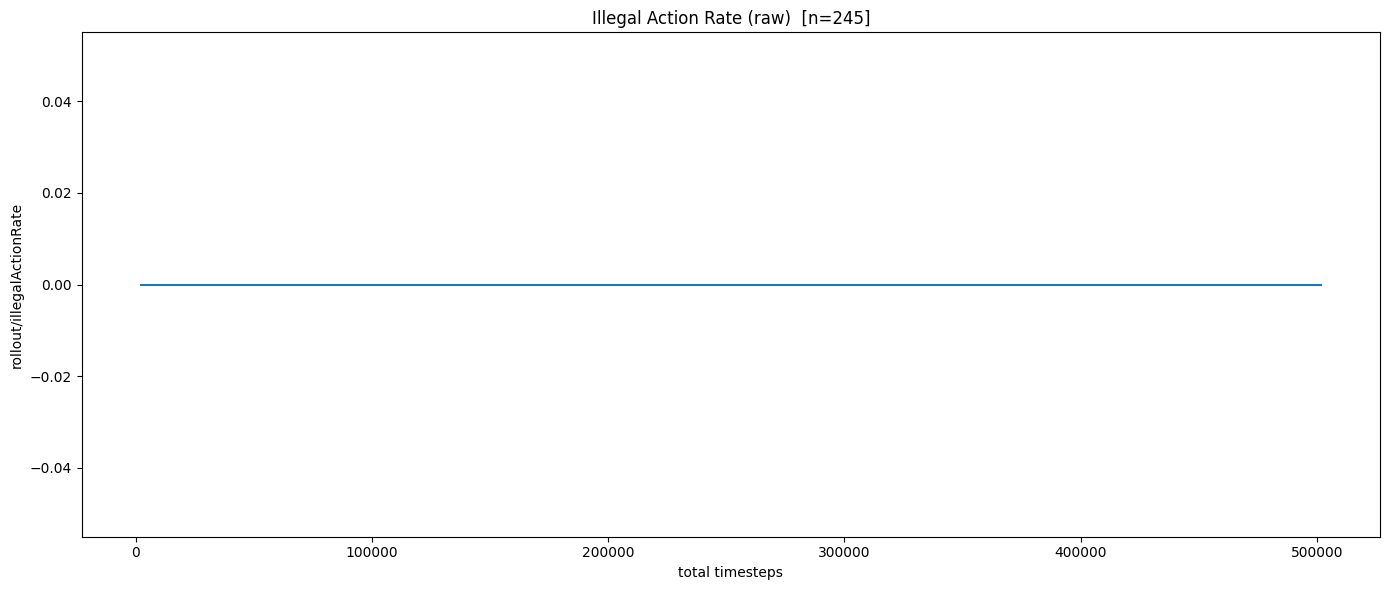

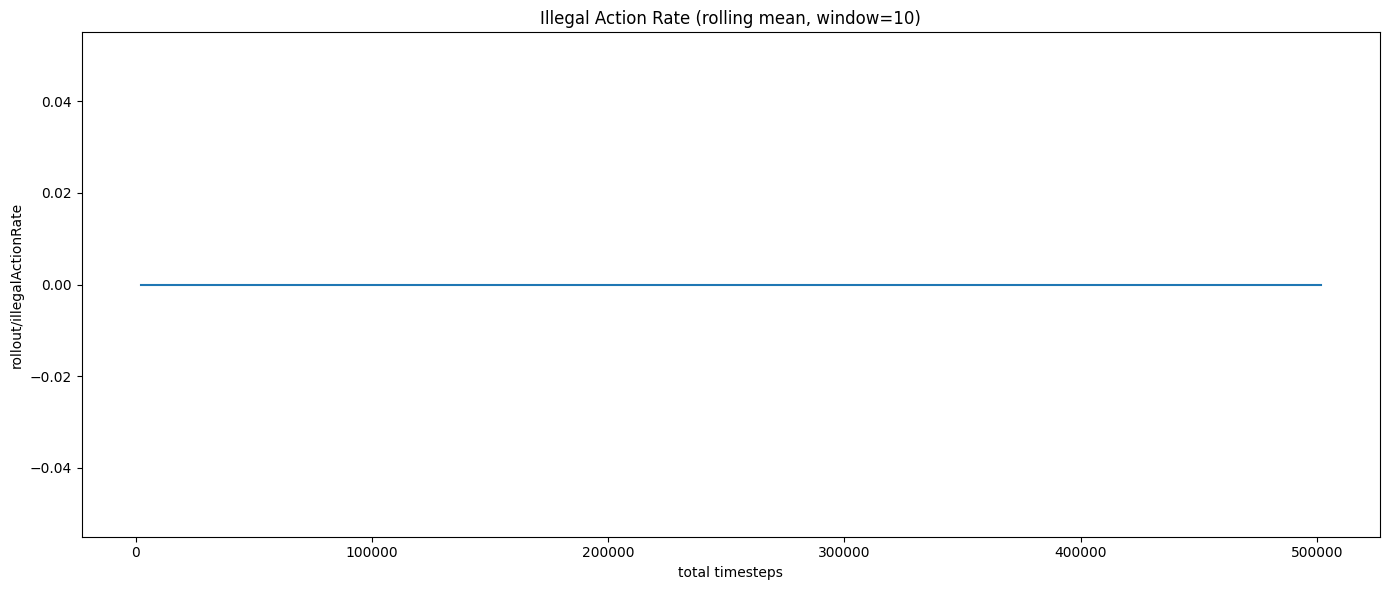

[rollout/millsPerEpisode] non-NaN points: 245
 time/total_timesteps  rollout/millsPerEpisode
                 2048                      7.0
                 4096                      7.0
                 6144                      4.0
                 8192                      1.0
                10240                      1.0
                12288                      7.0
                14336                      7.0
                16384                      4.0
                18432                      7.0
                20480                      7.0


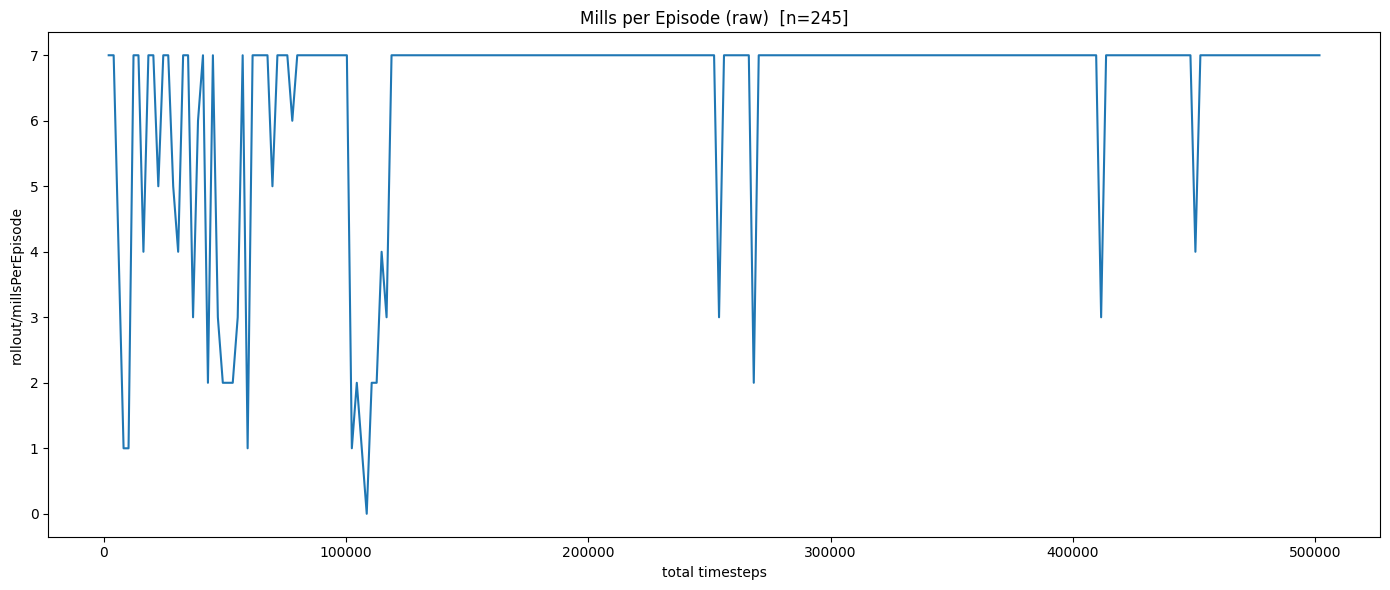

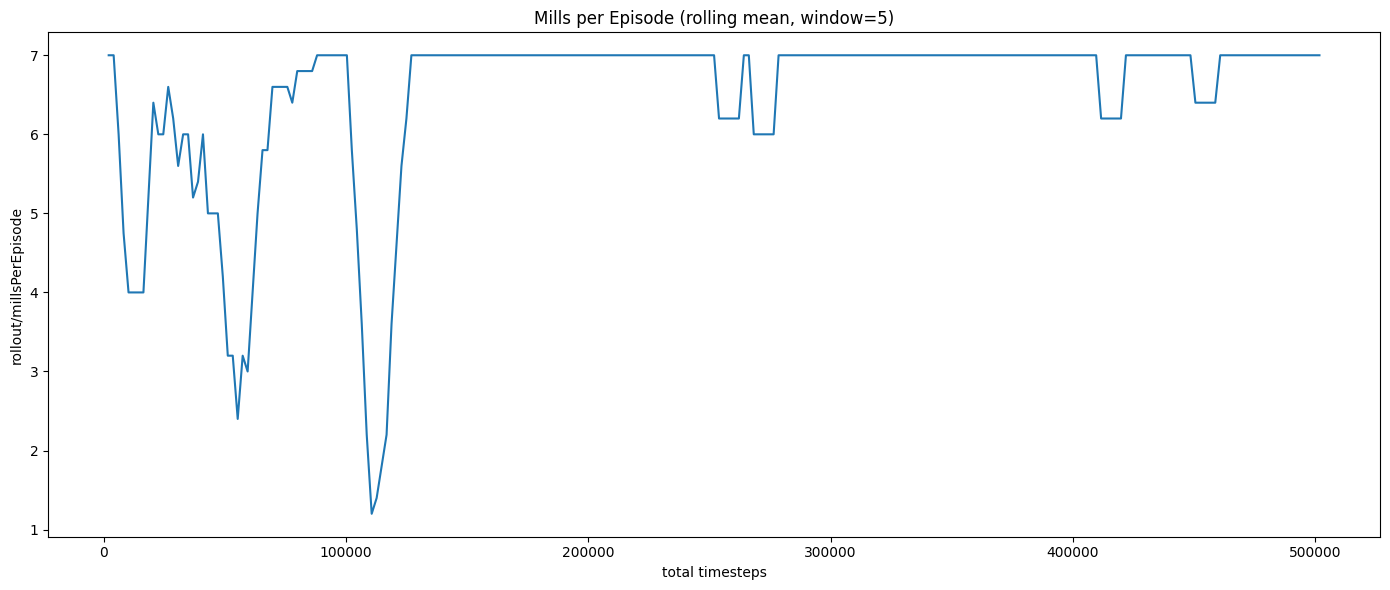

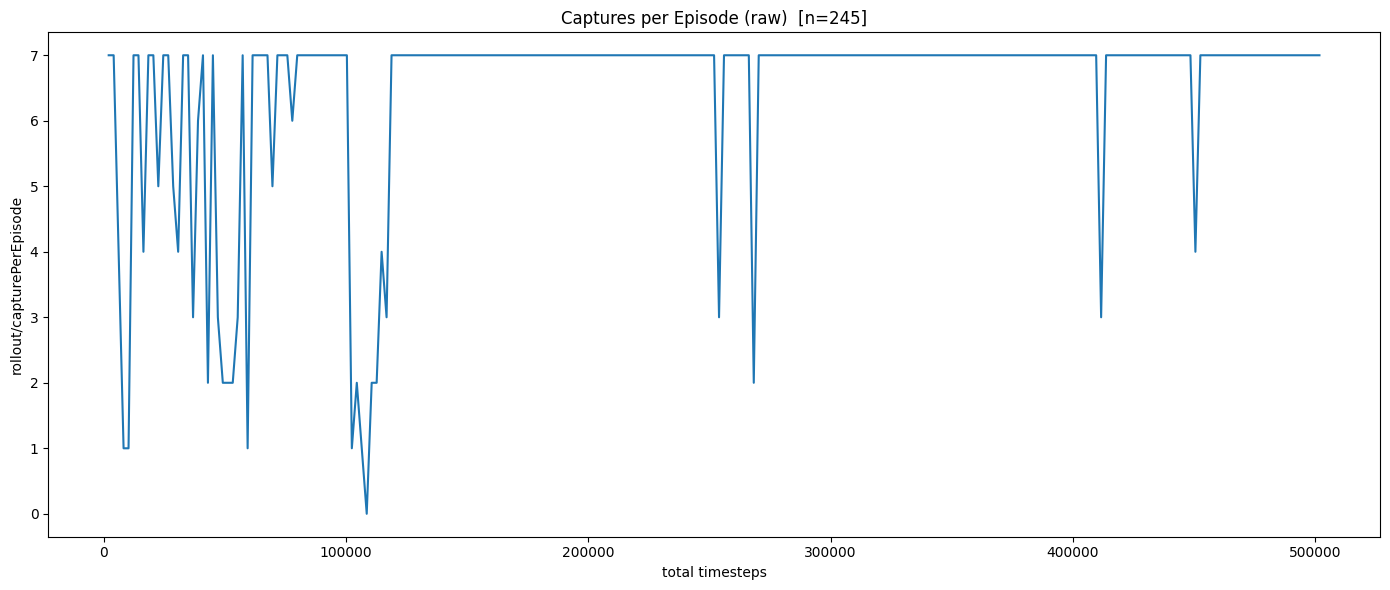

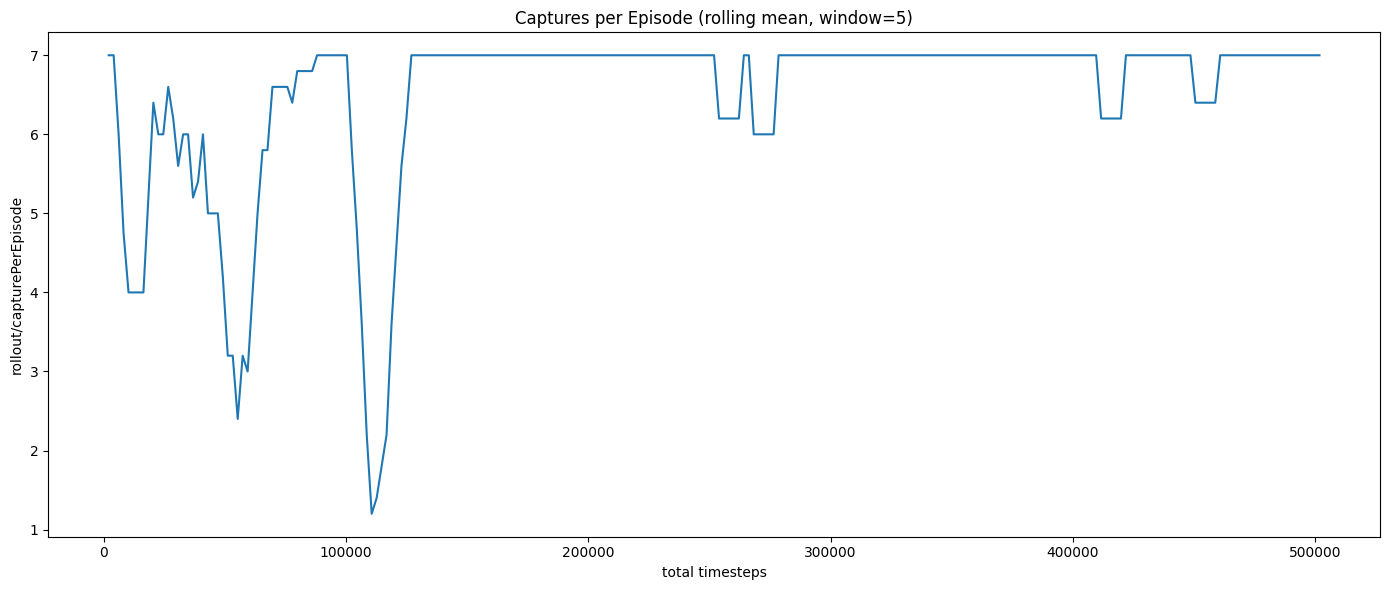

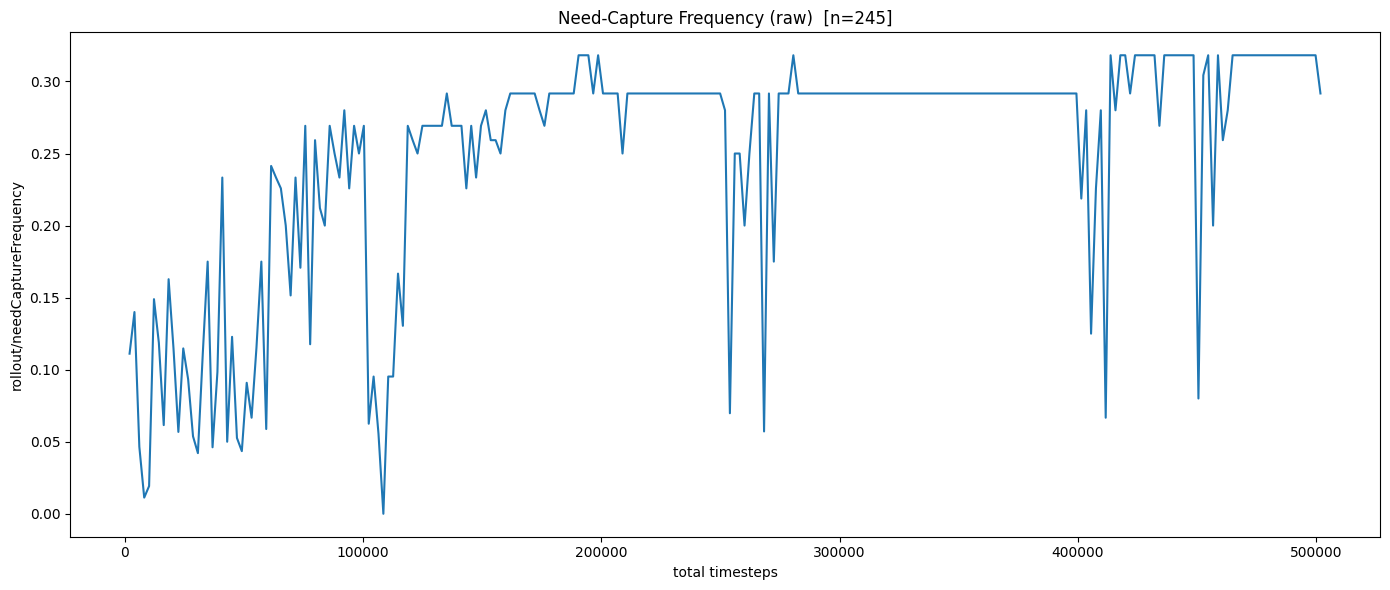

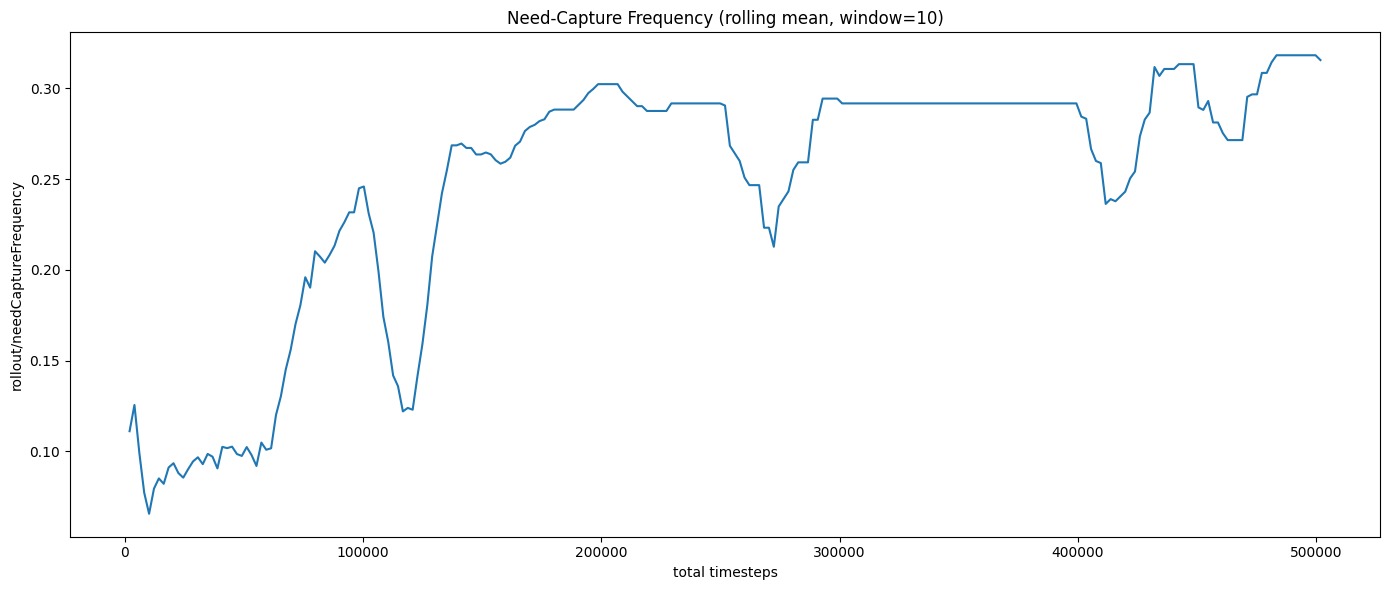

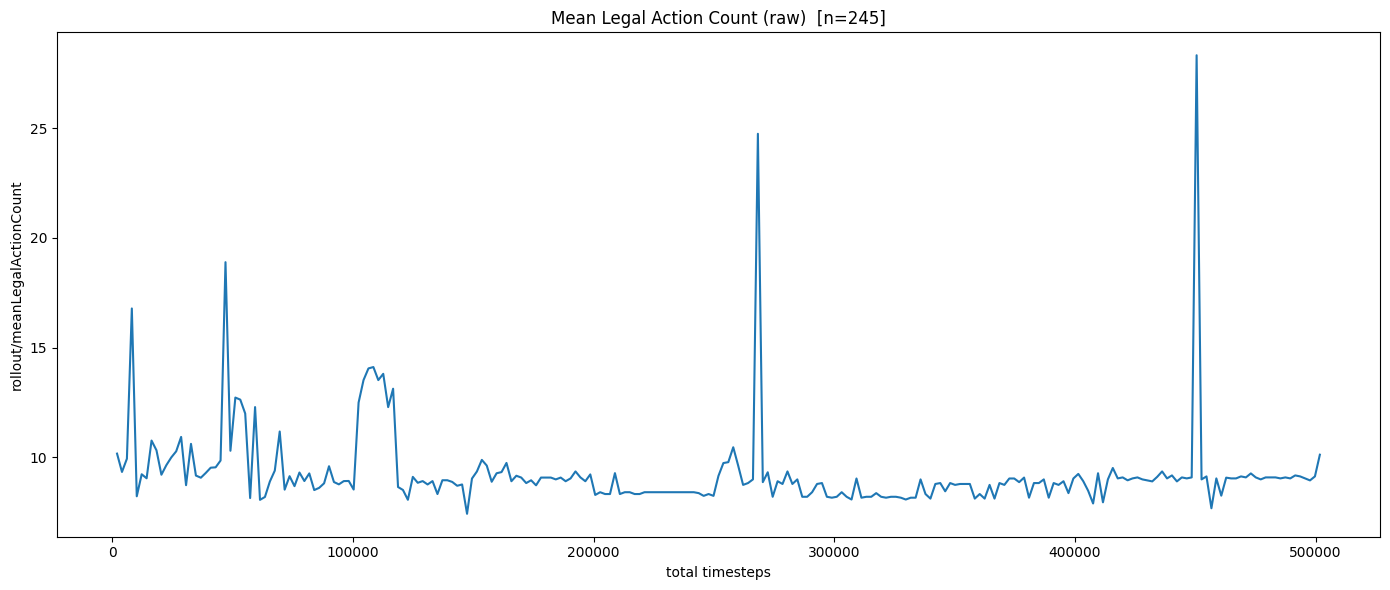

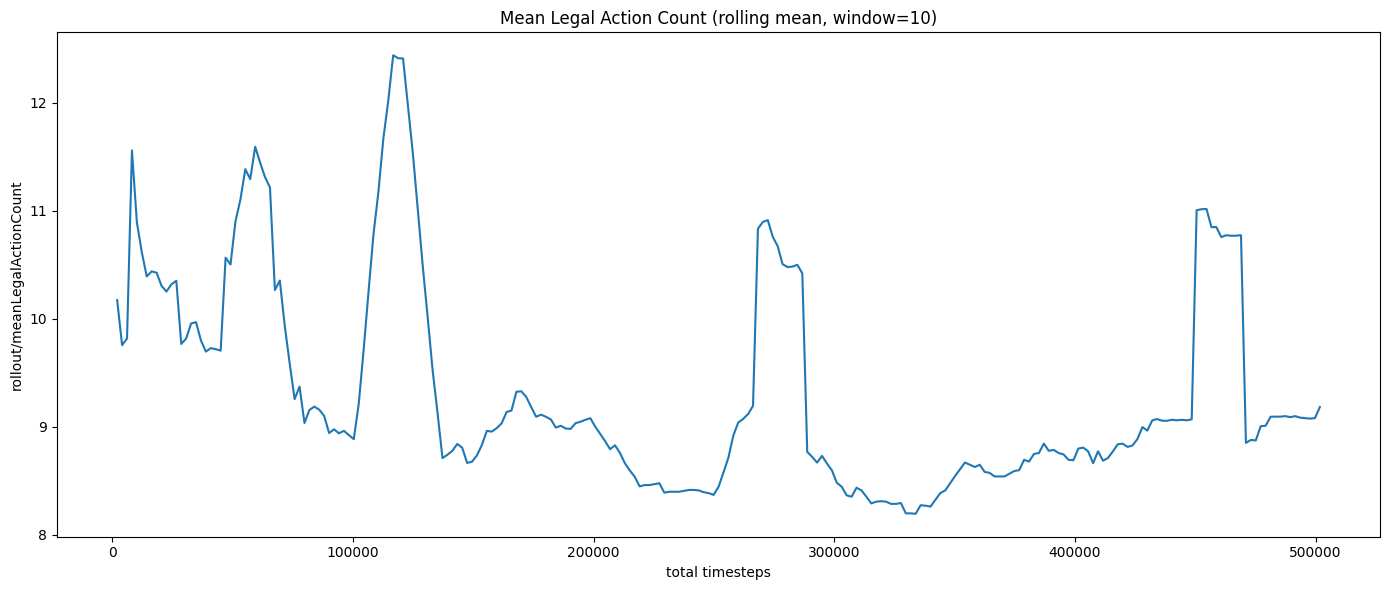

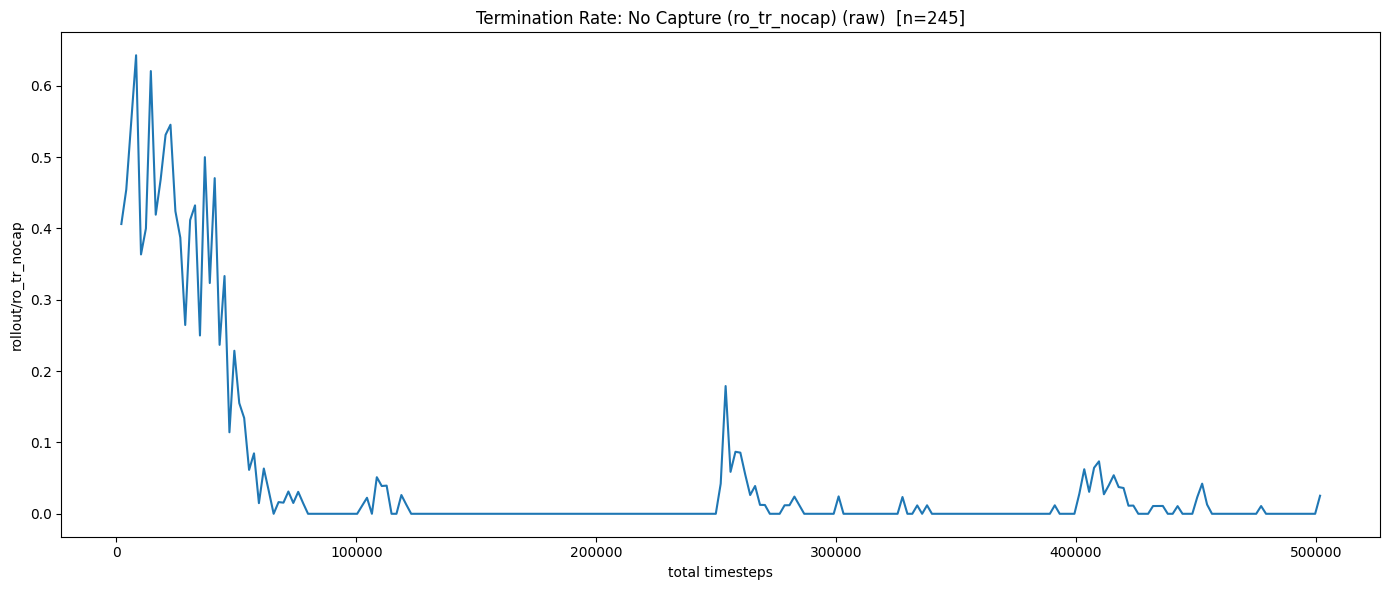

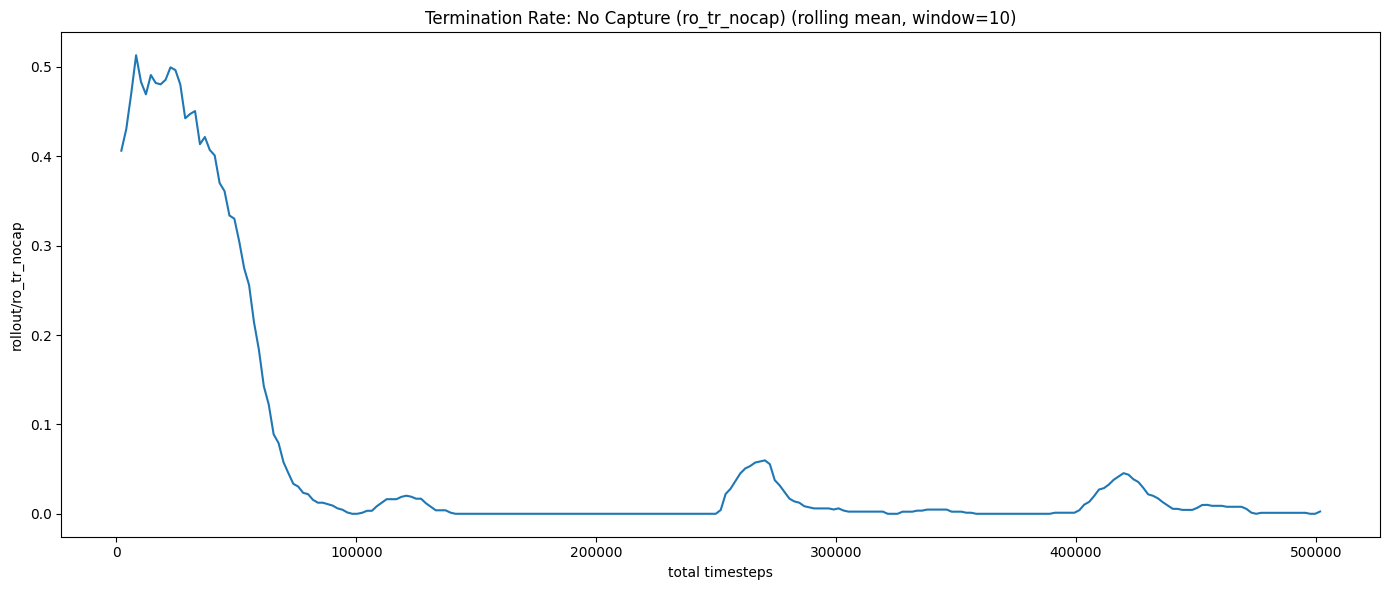

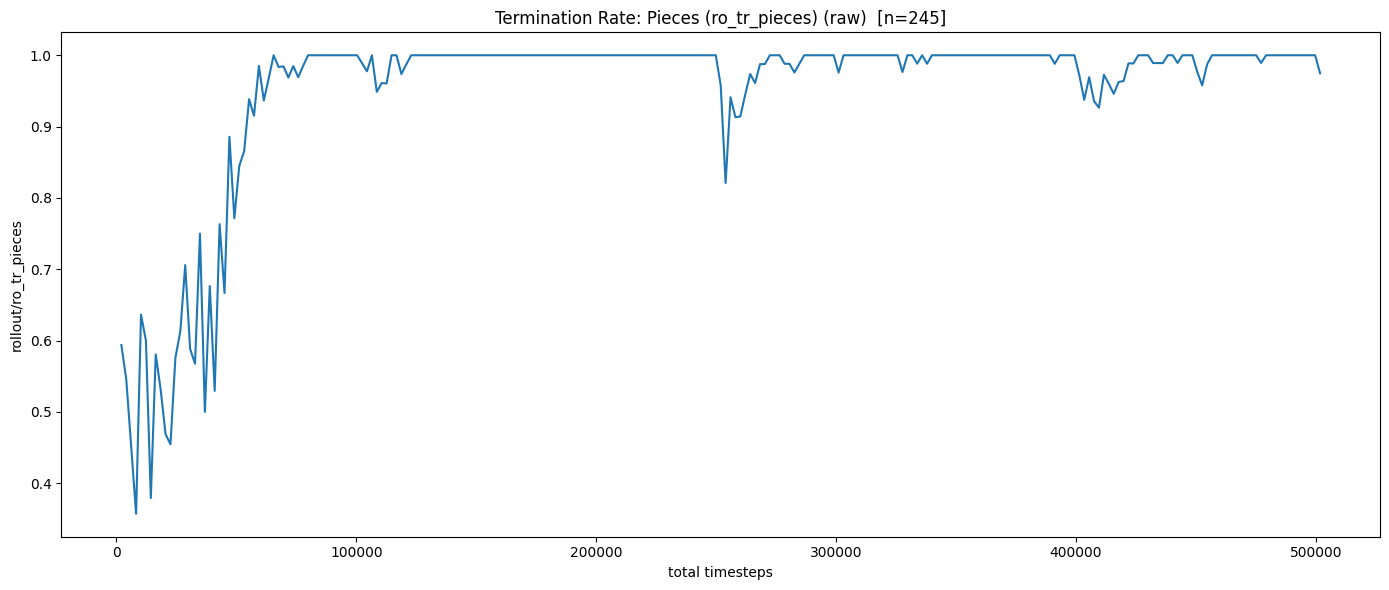

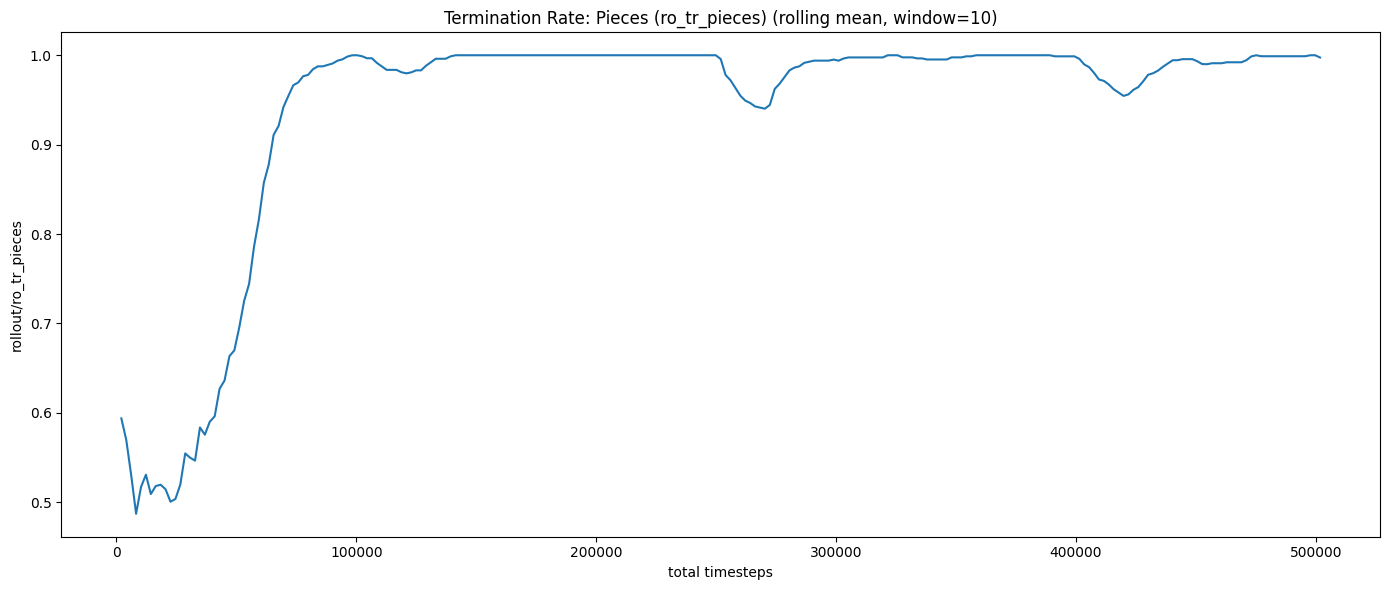

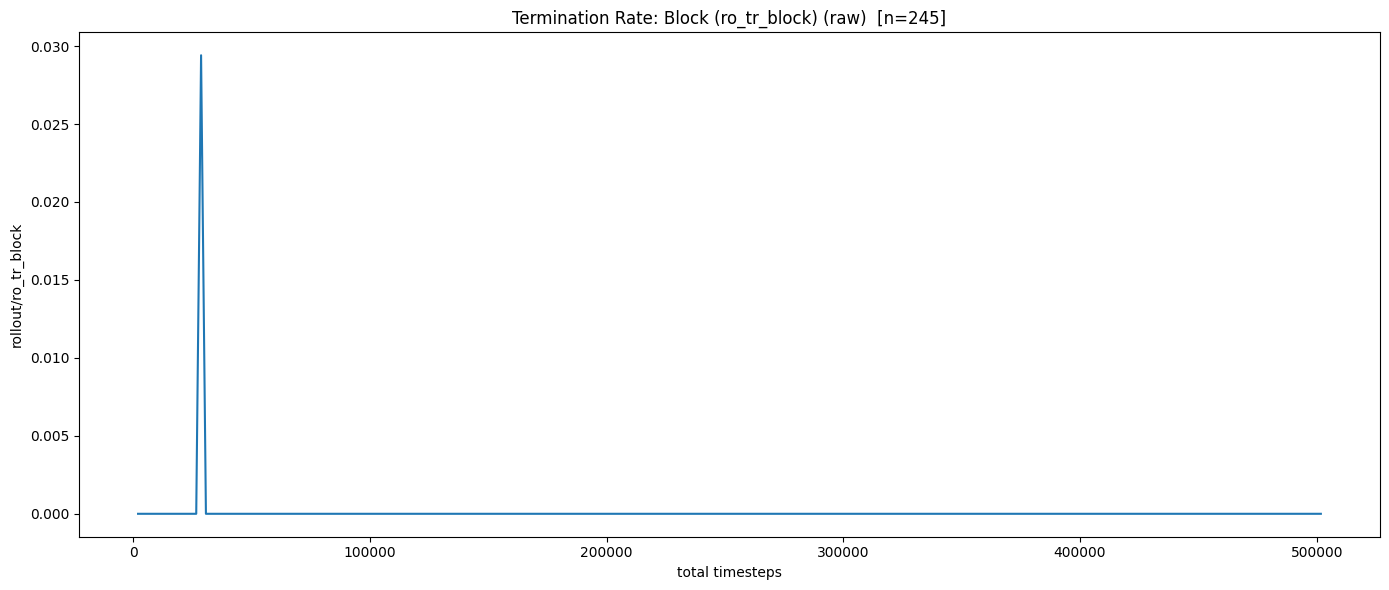

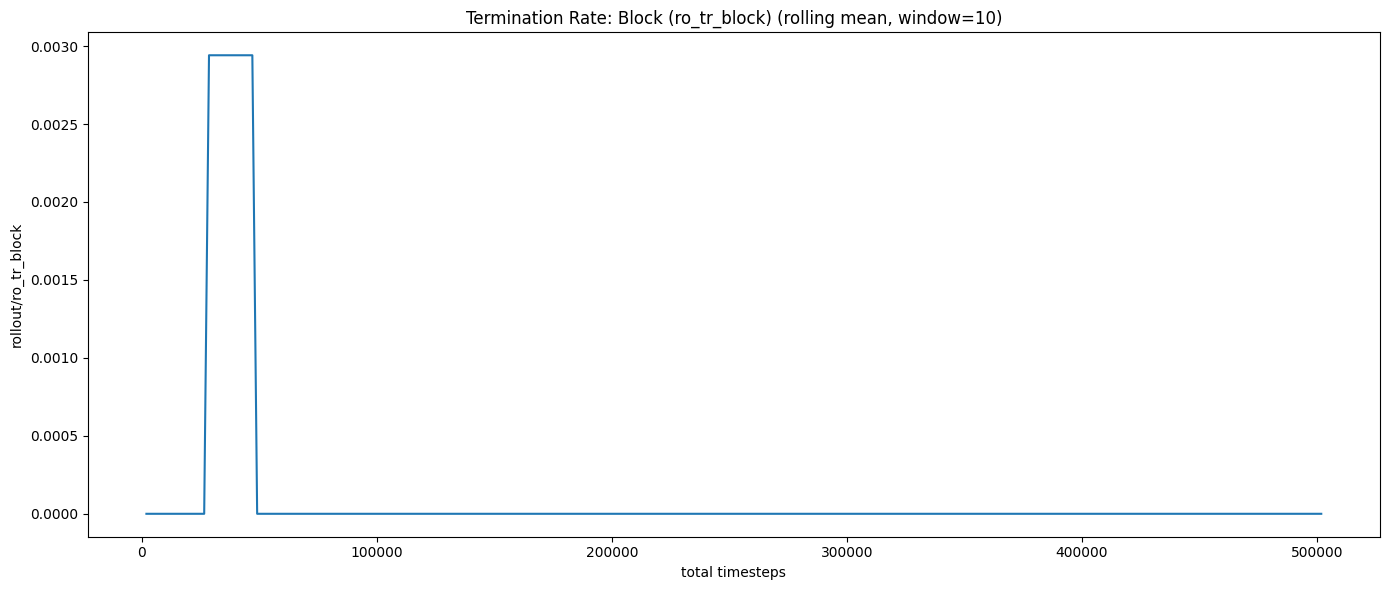

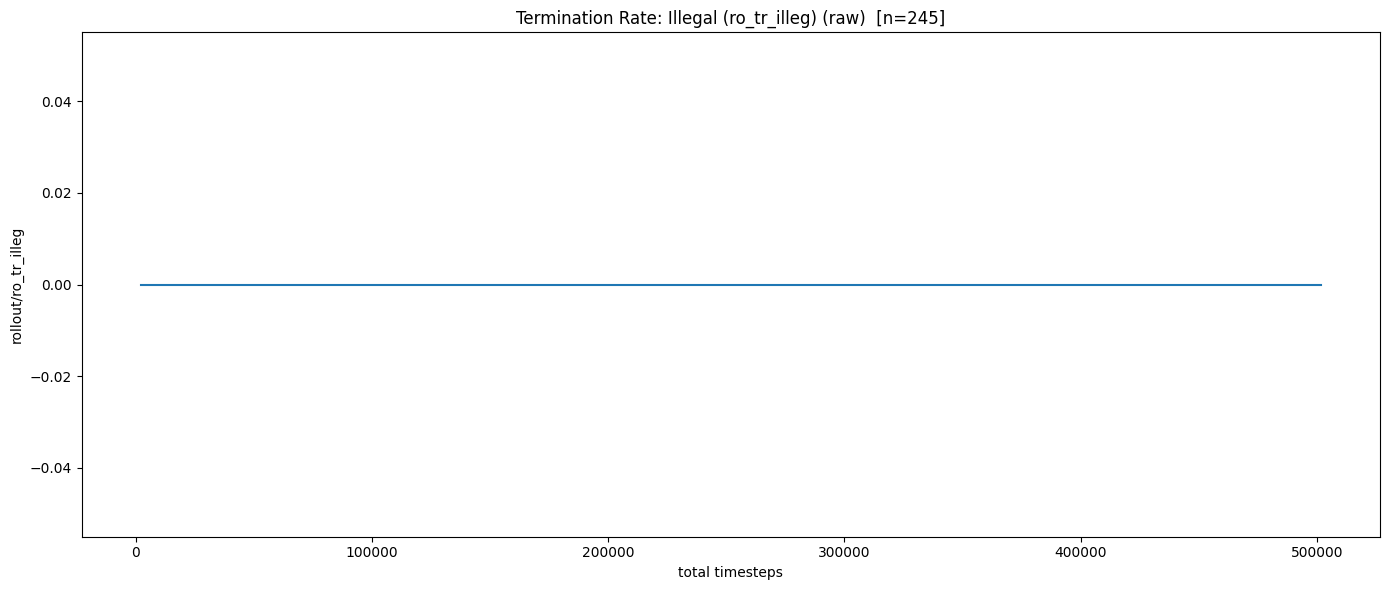

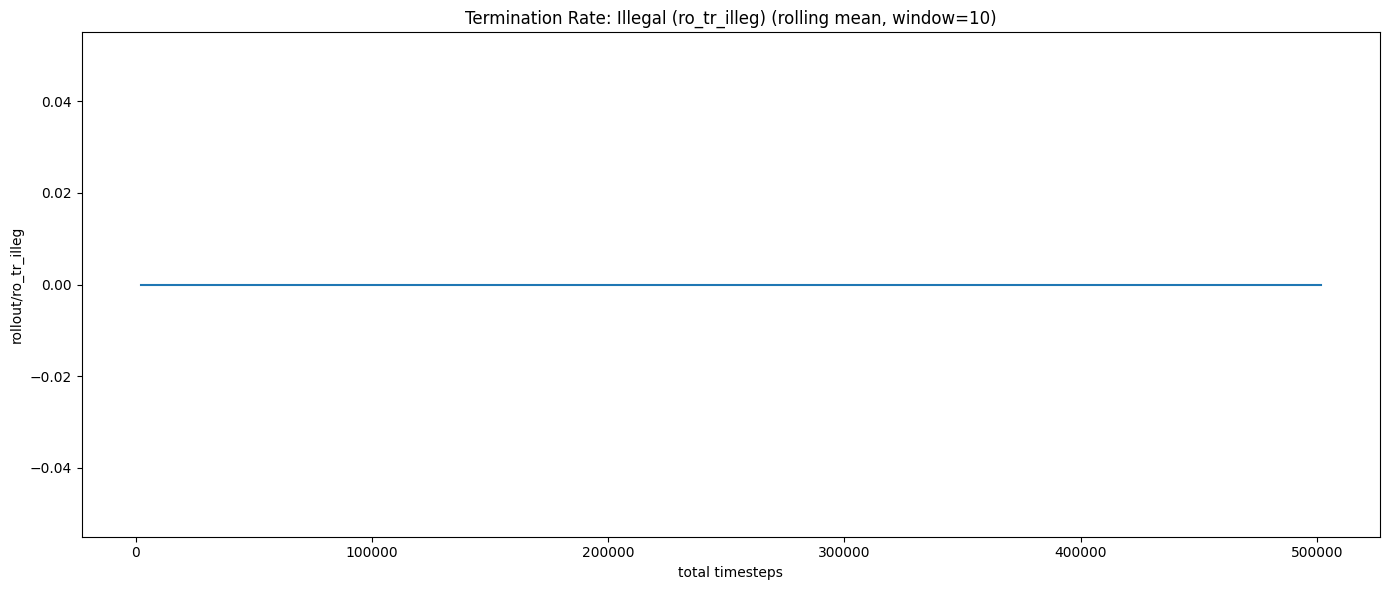

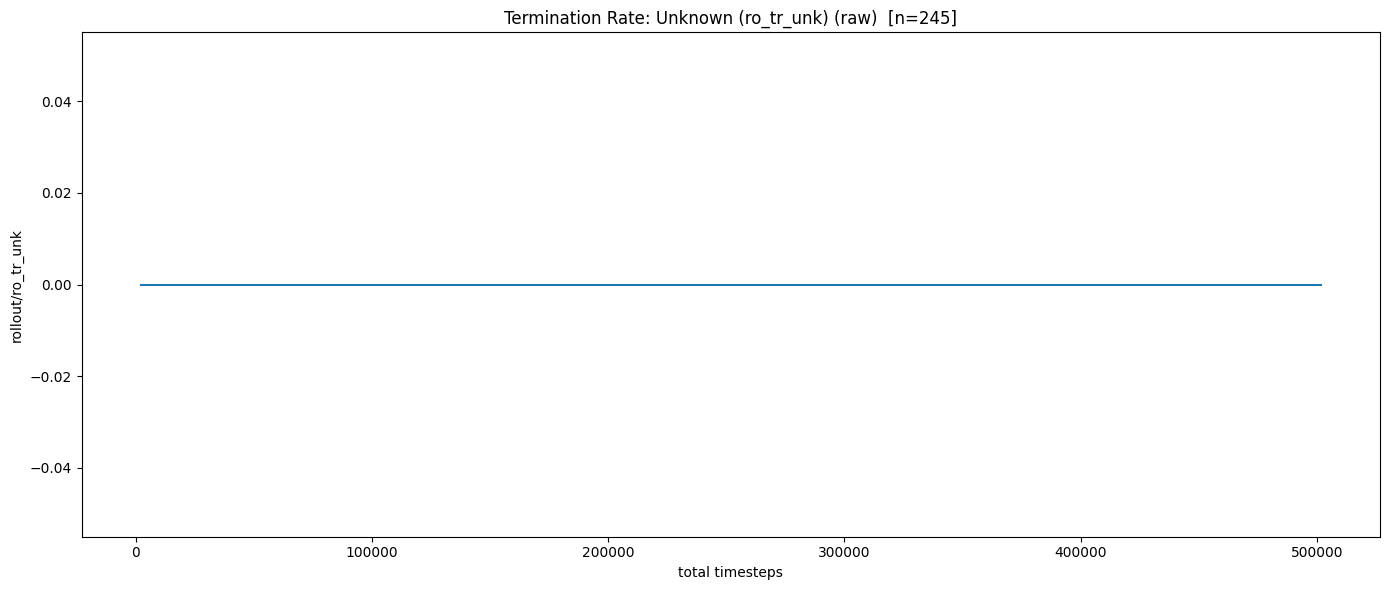

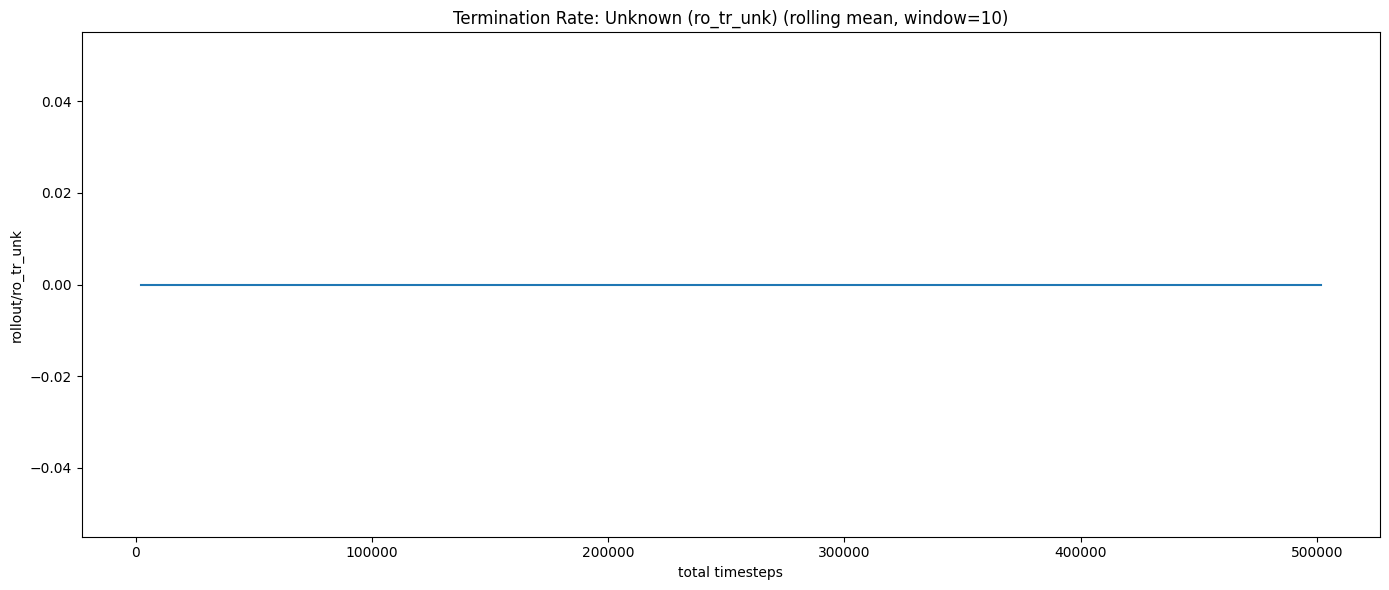

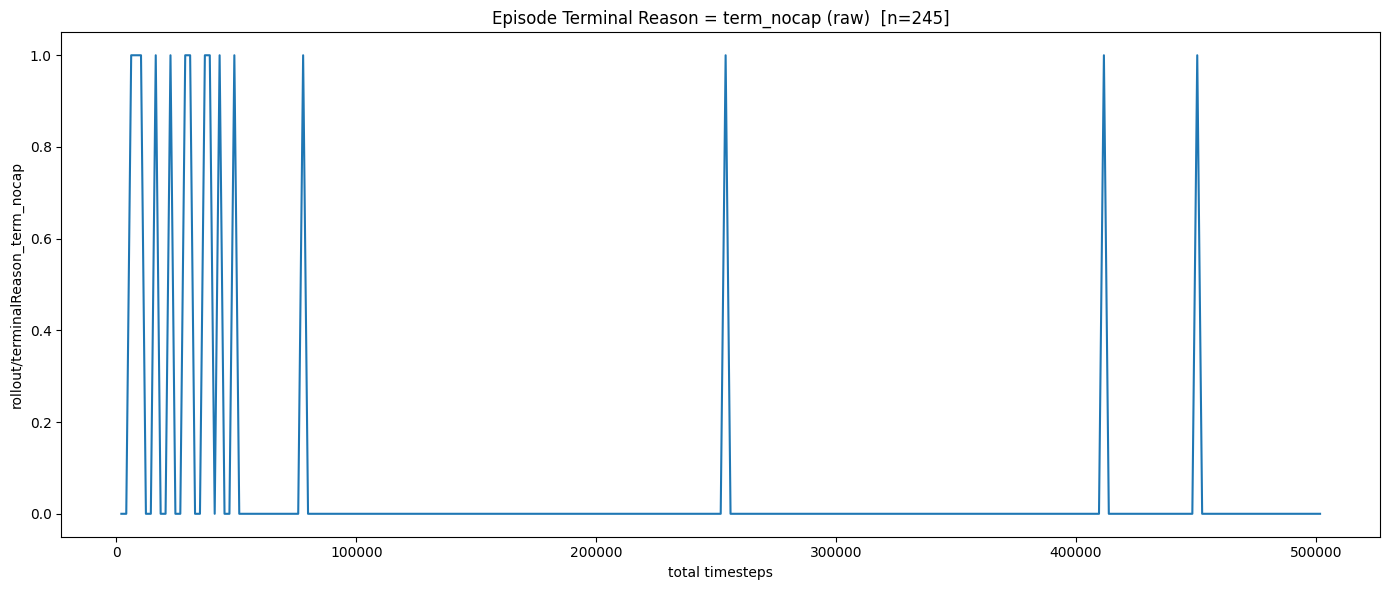

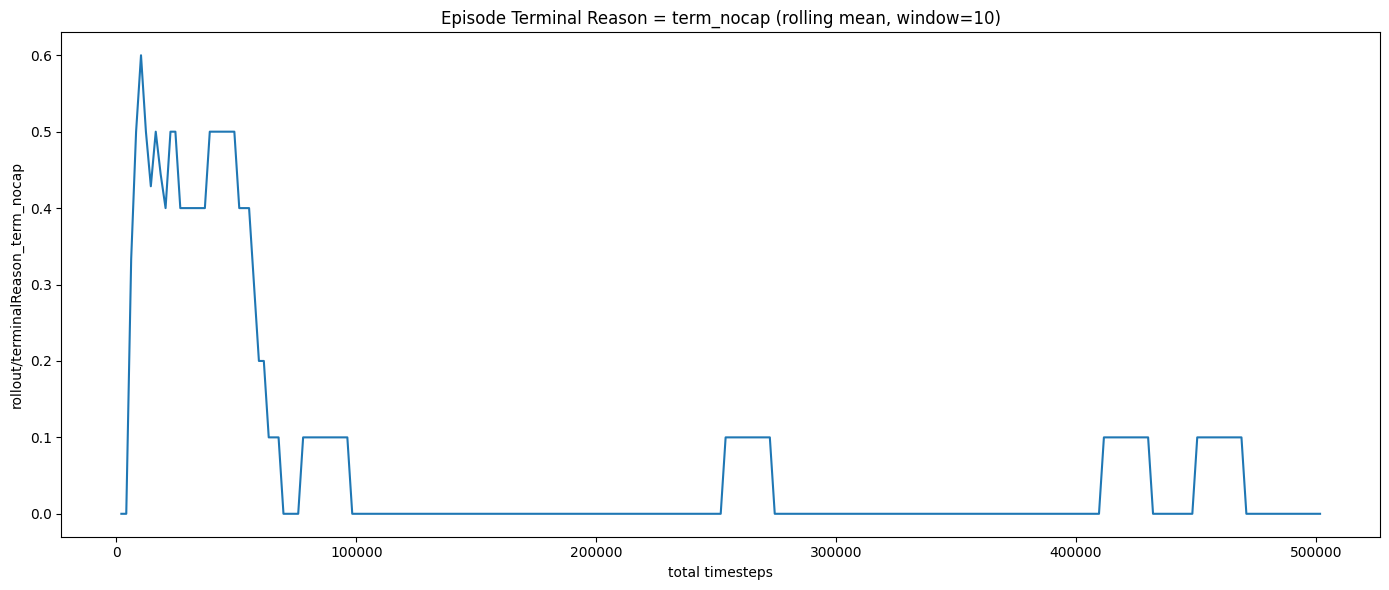

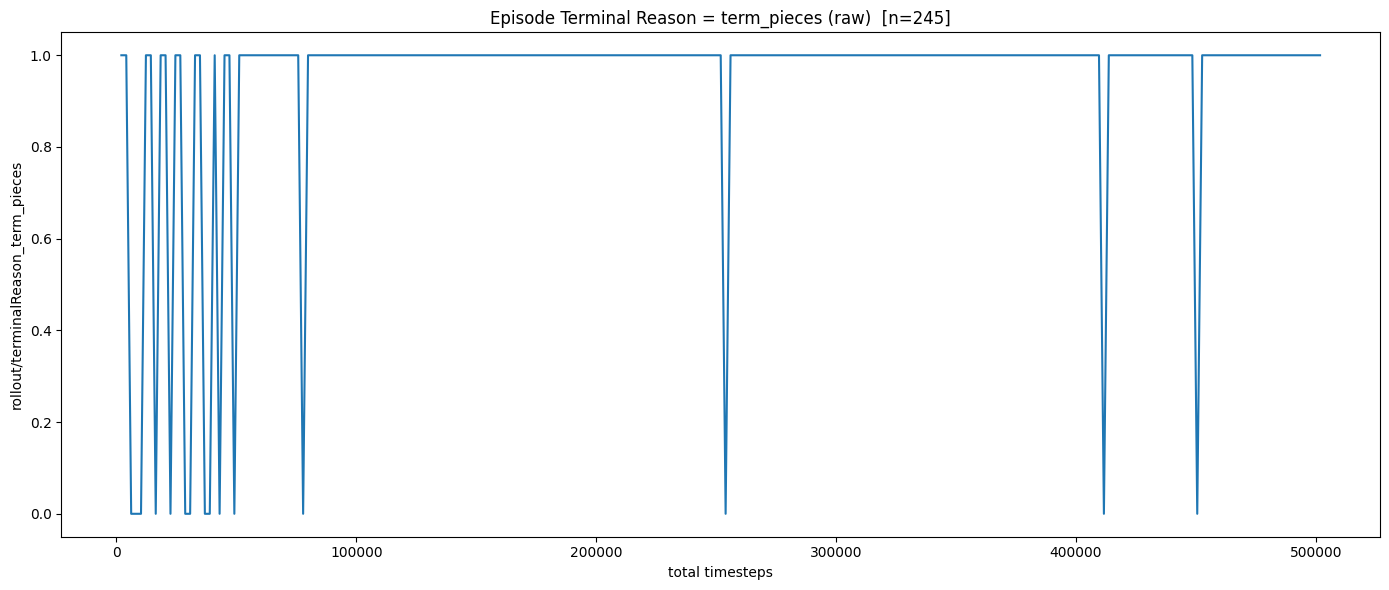

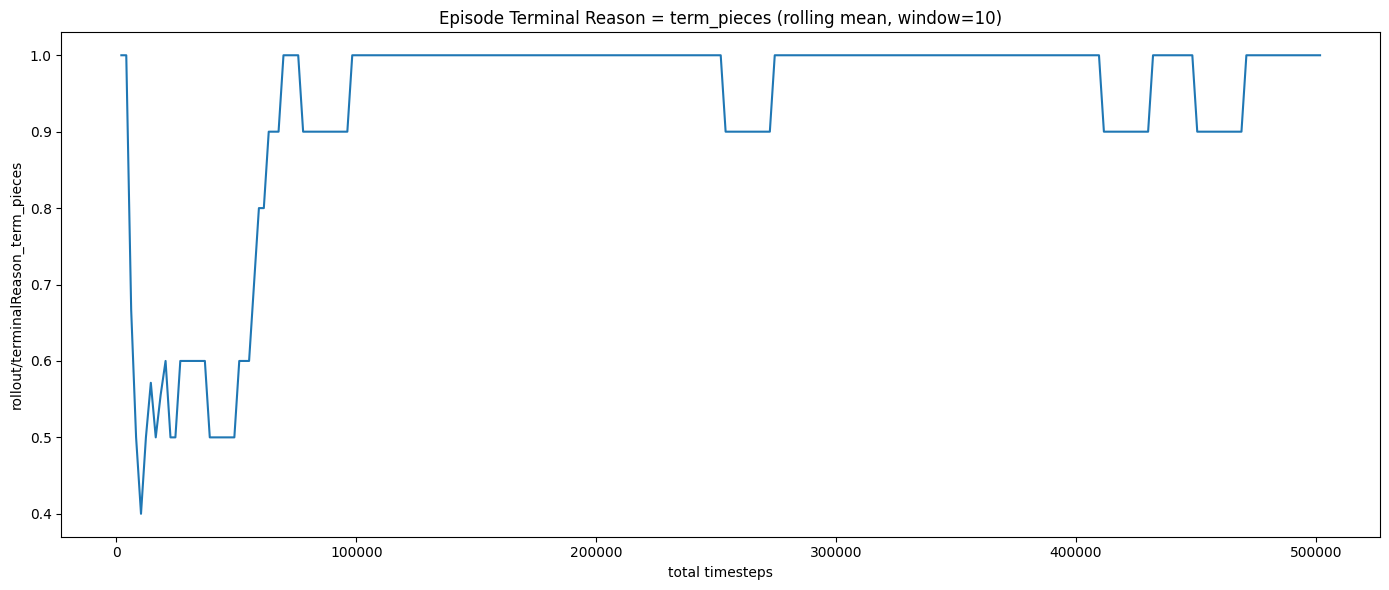

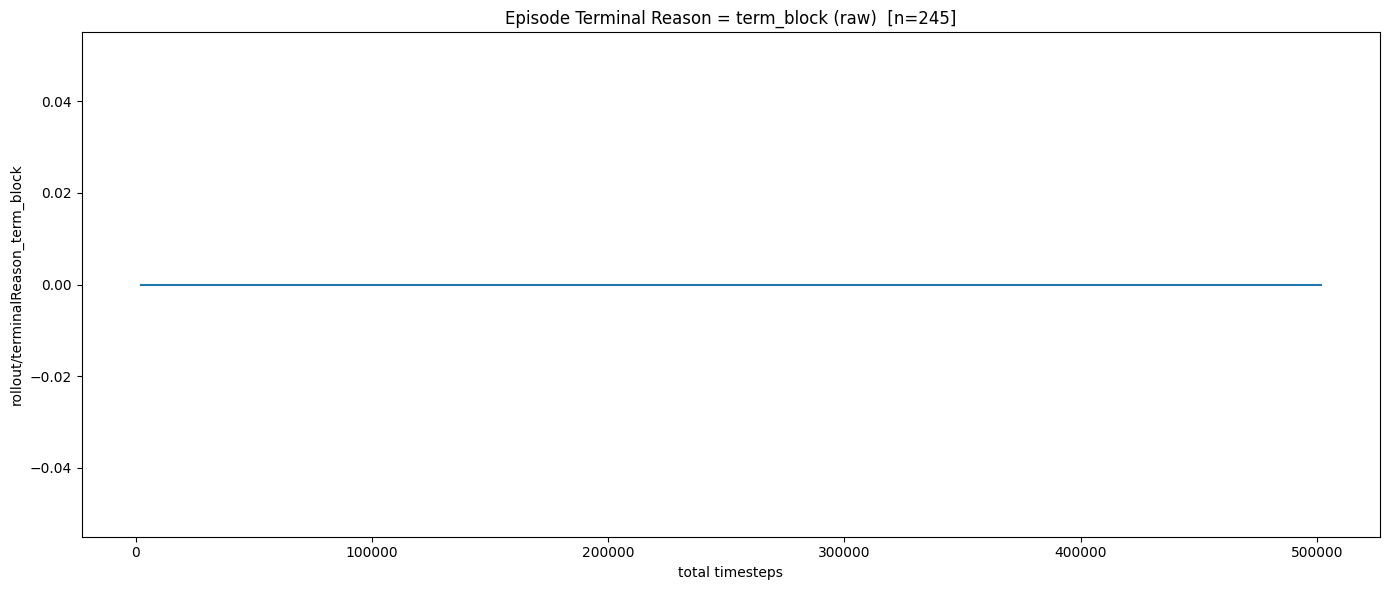

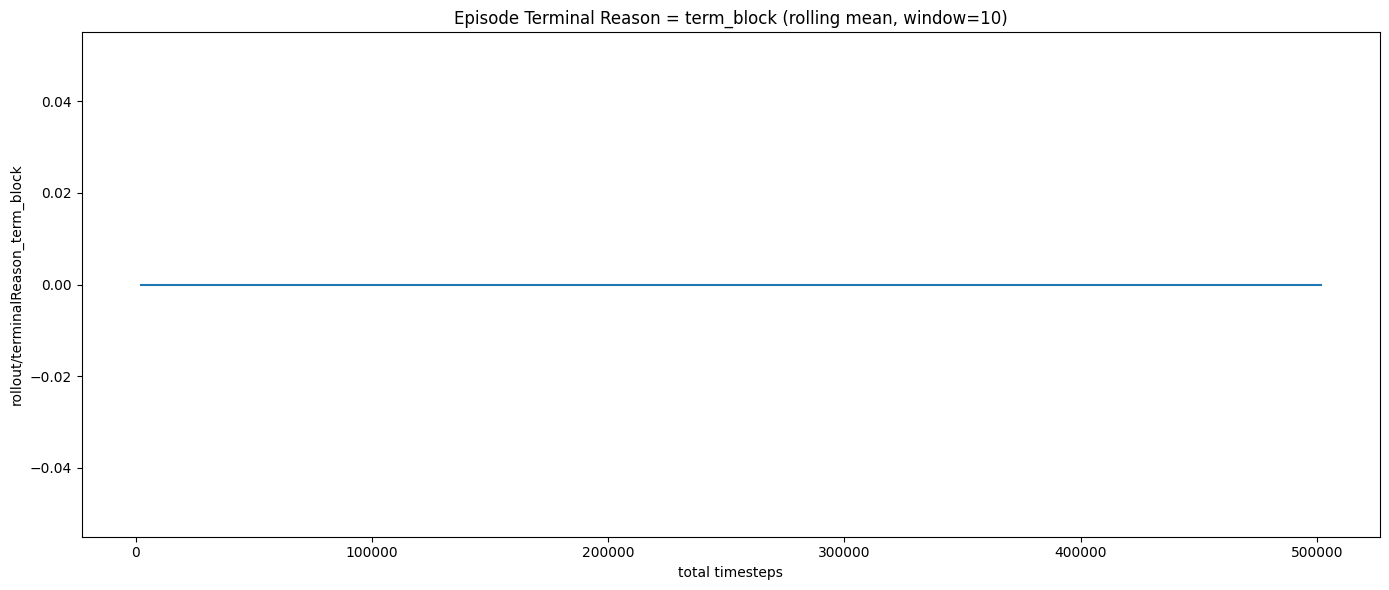

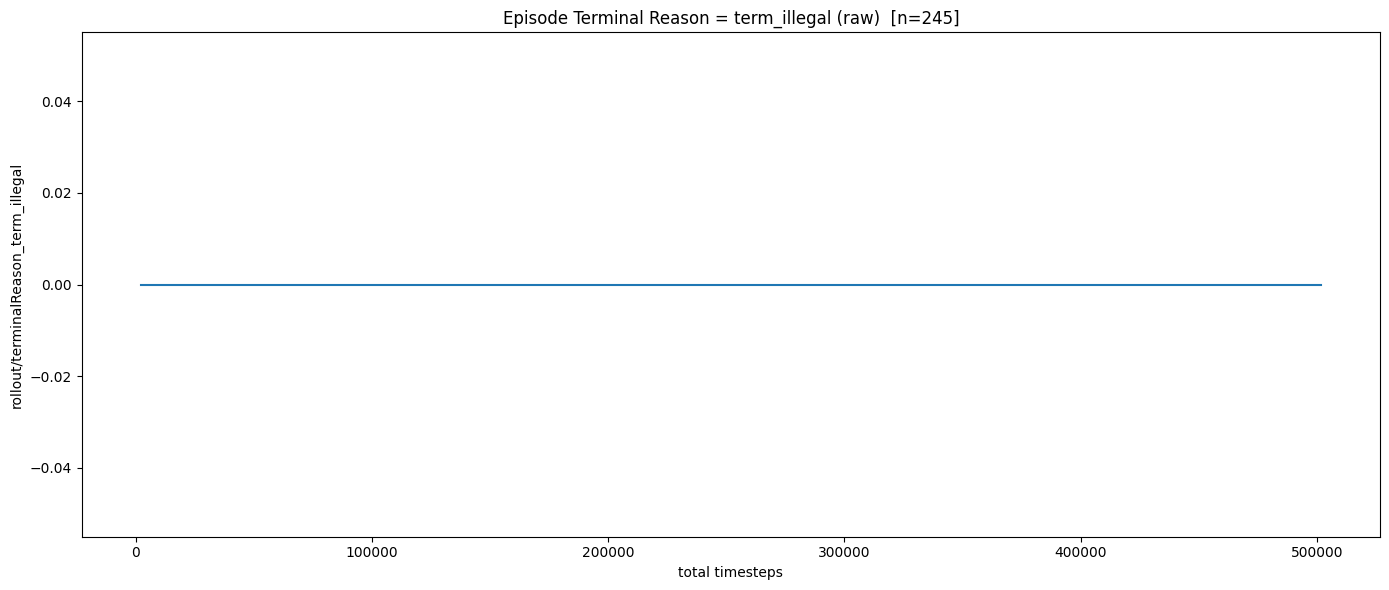

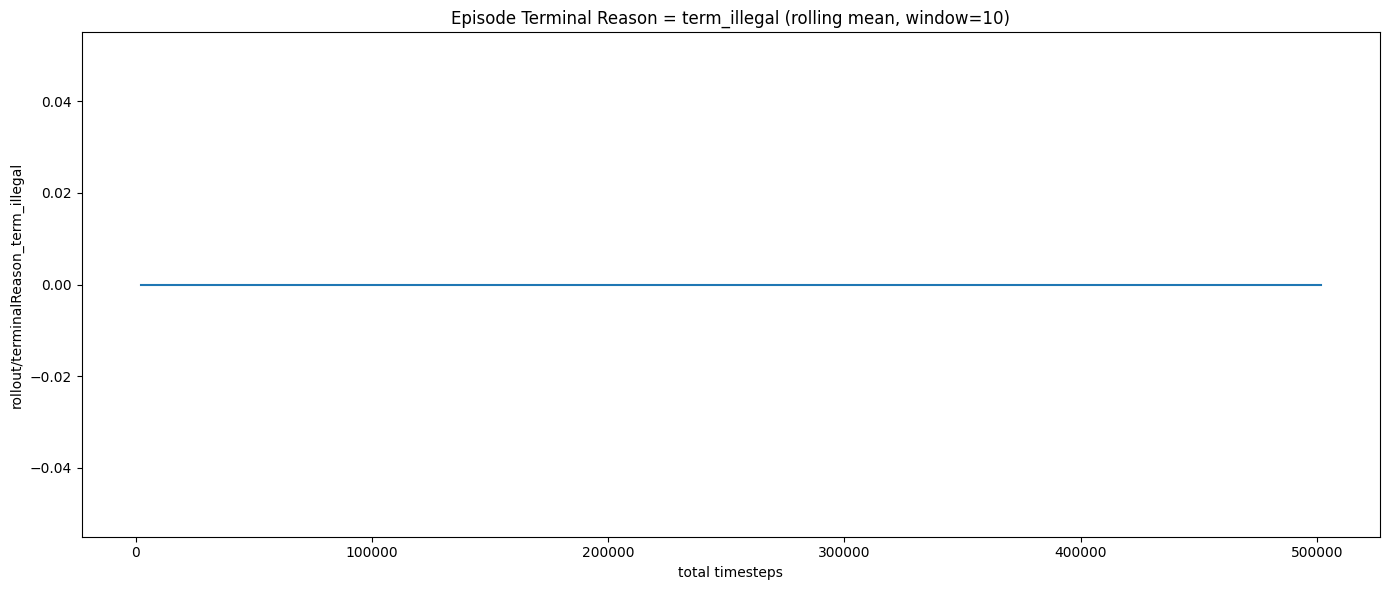

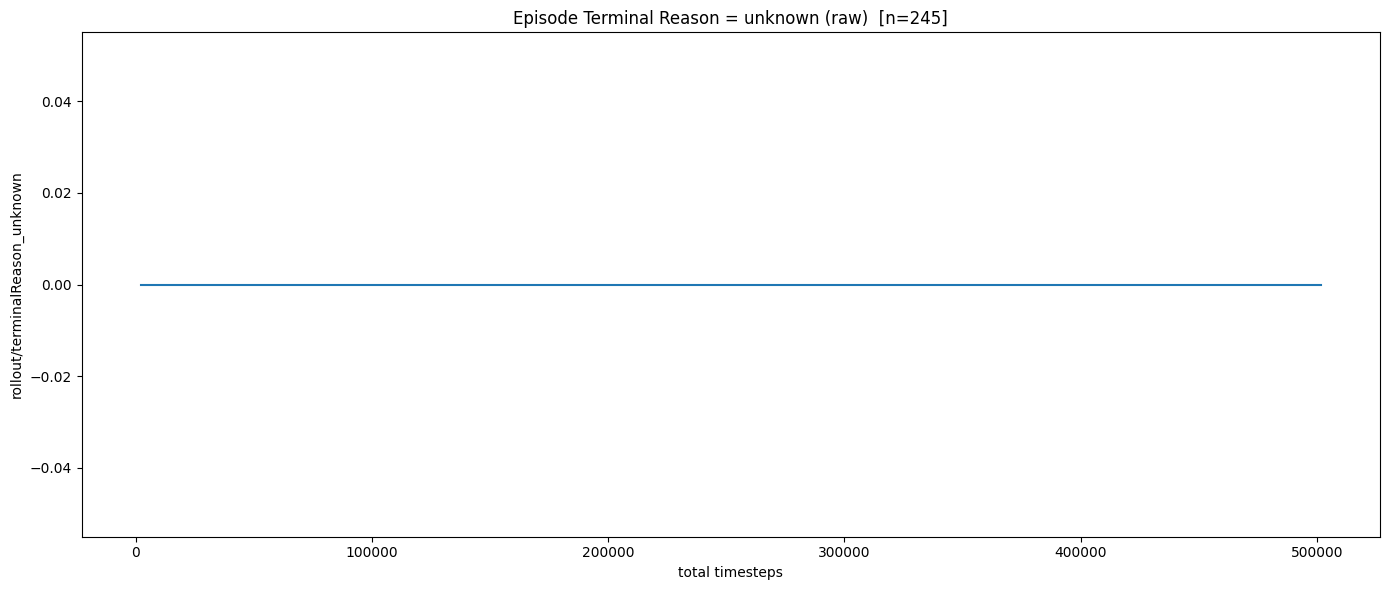

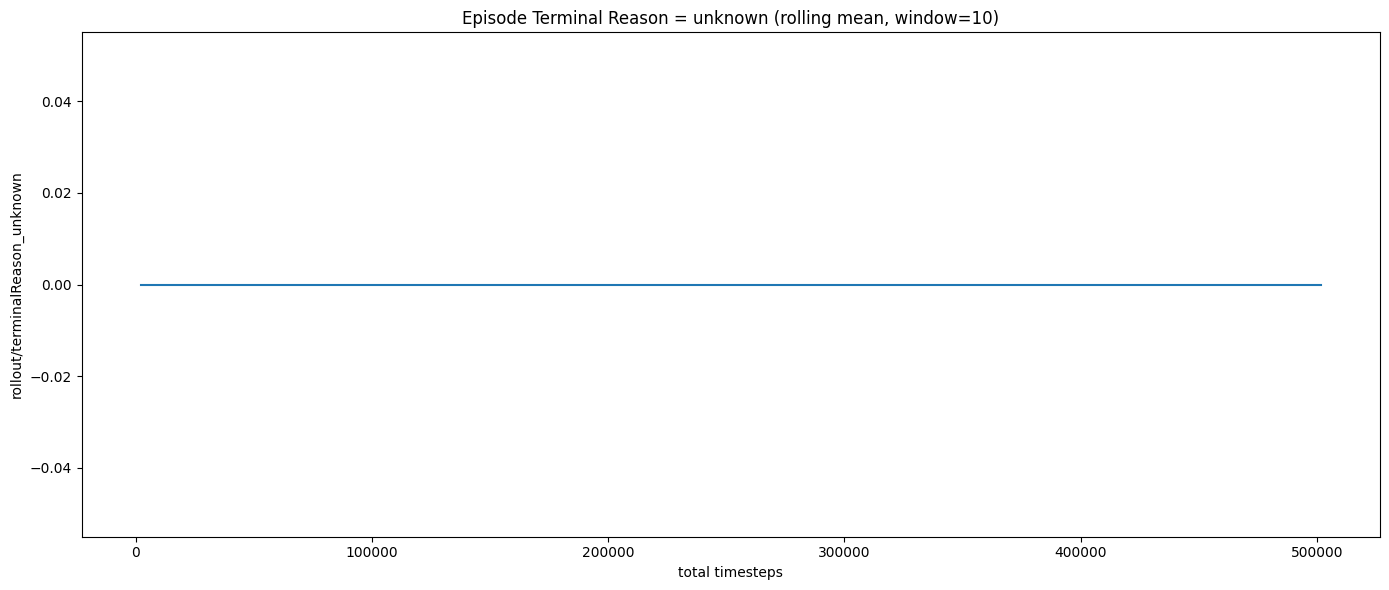

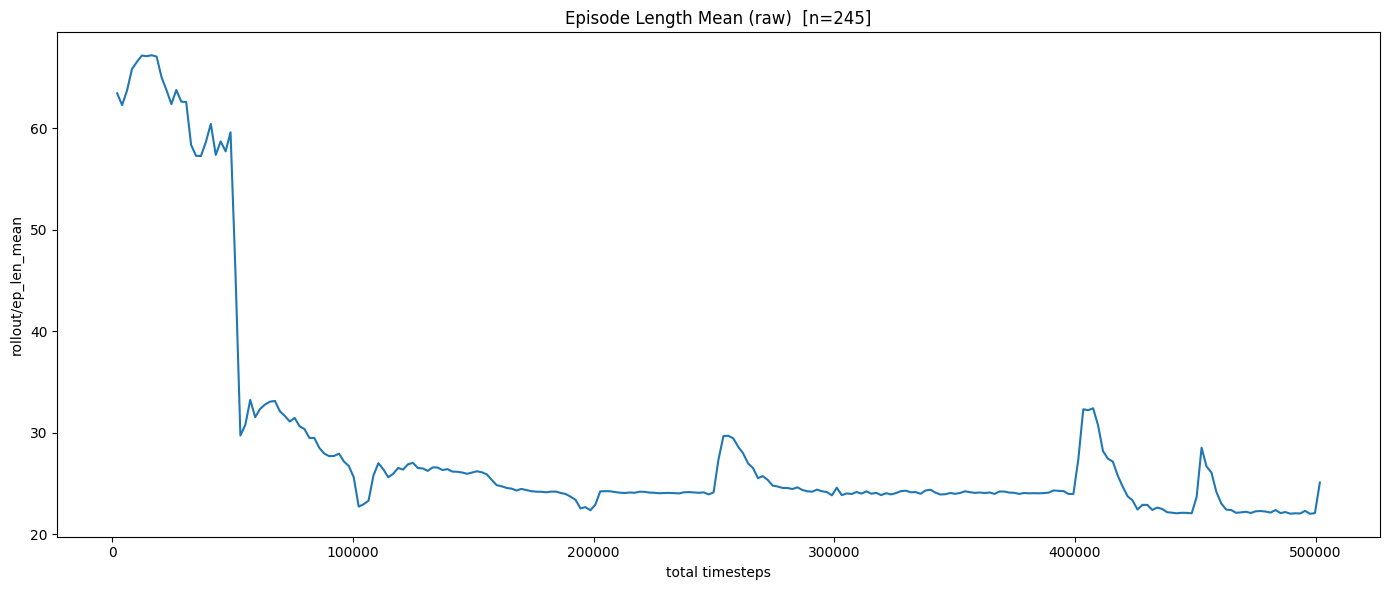

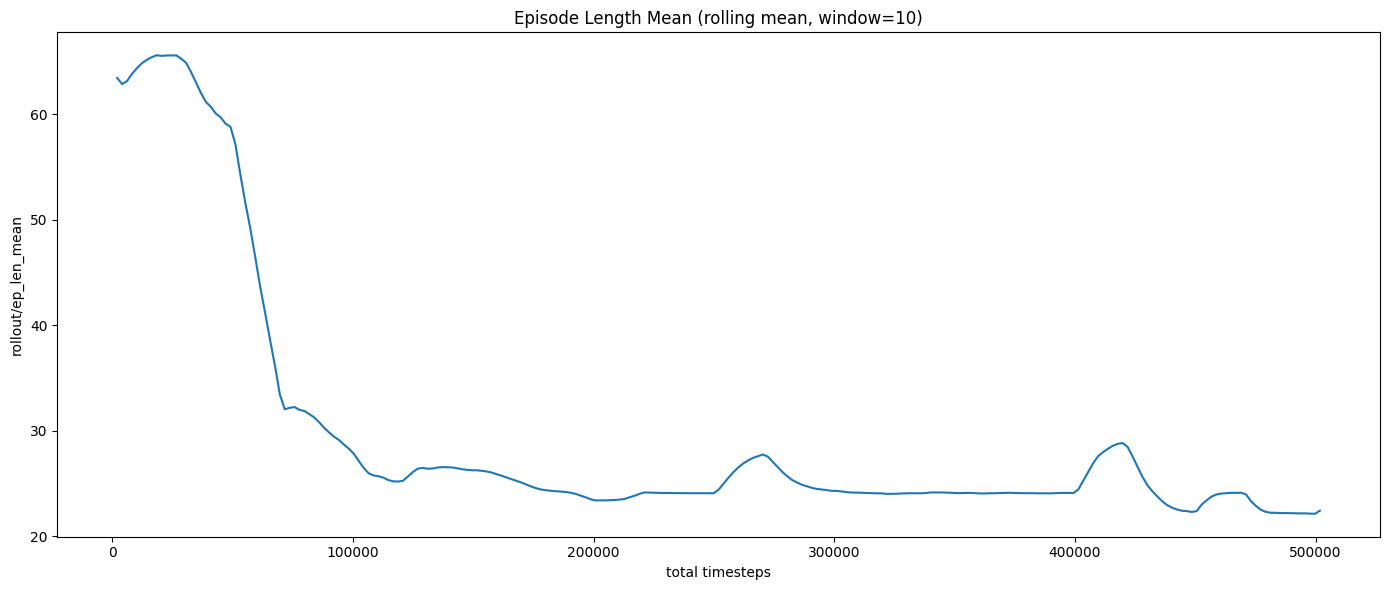

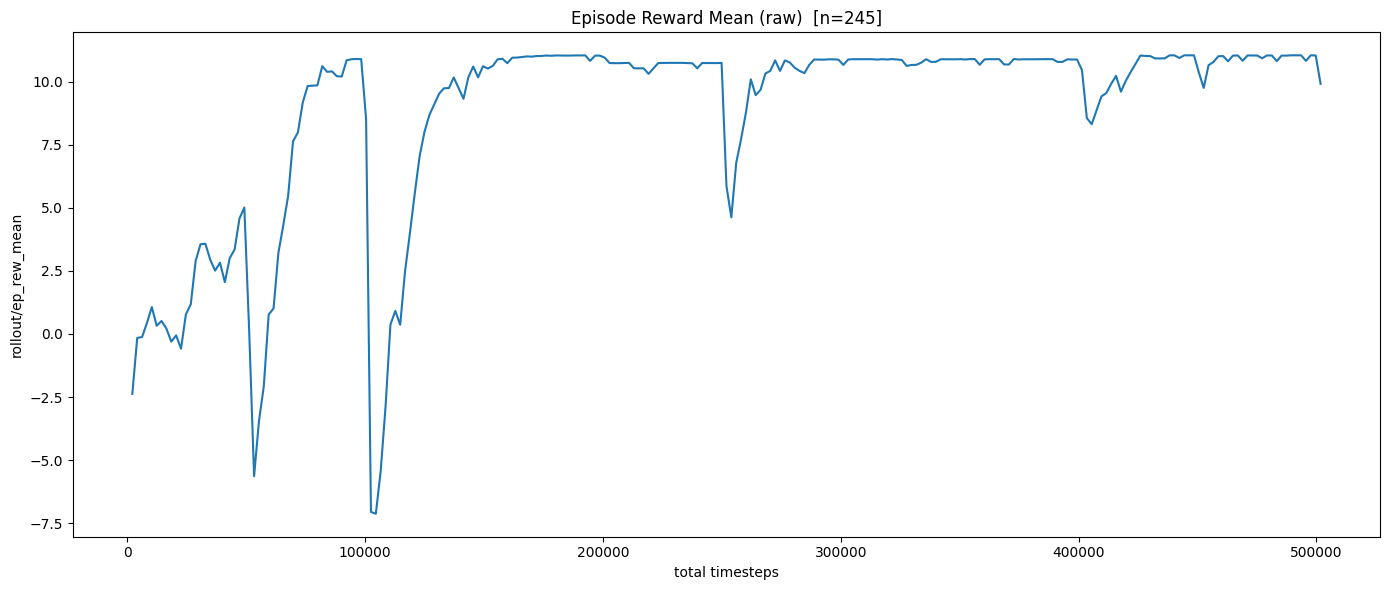

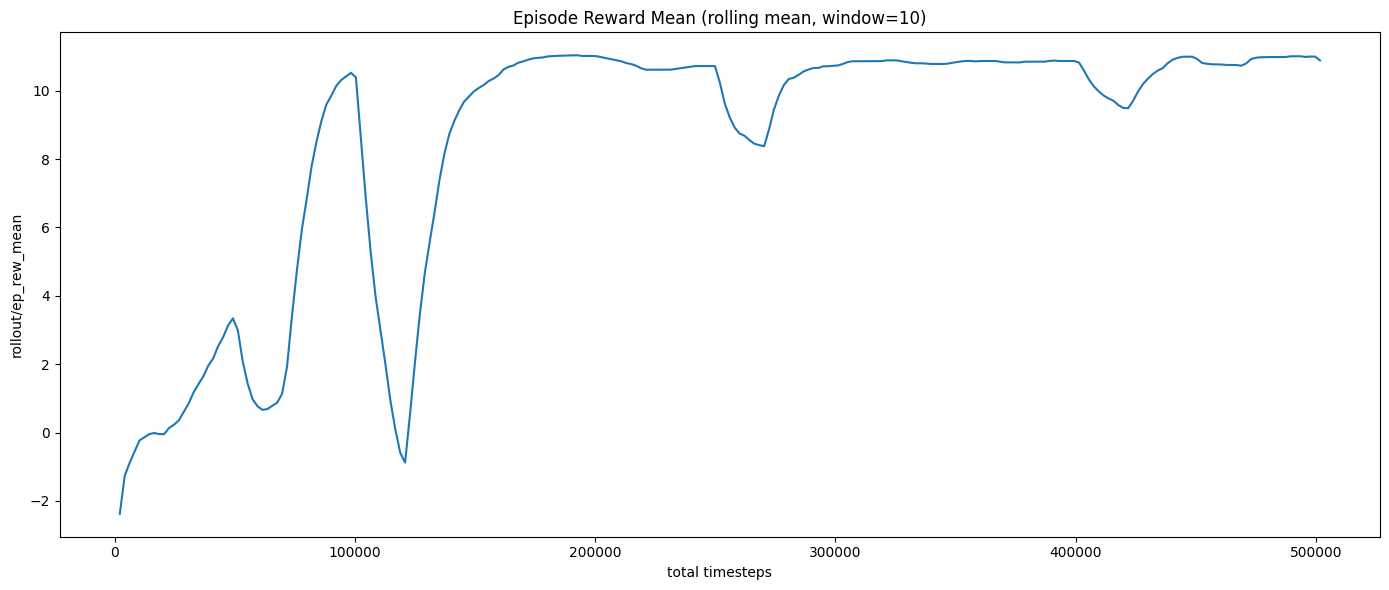

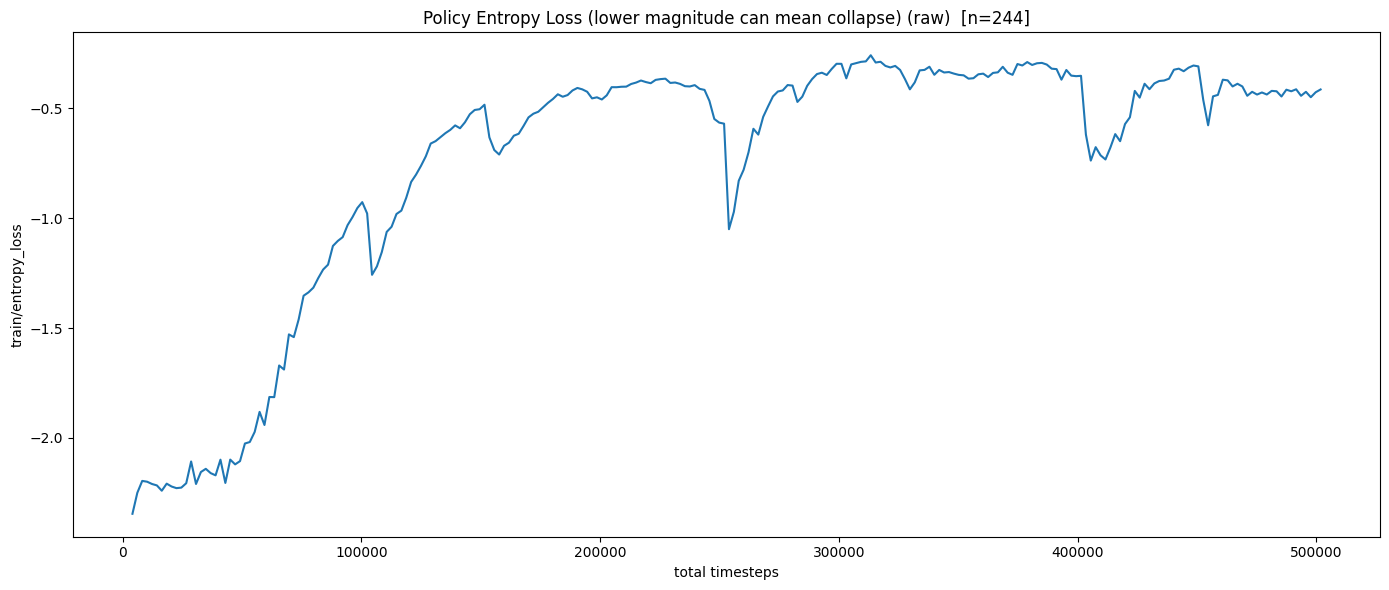

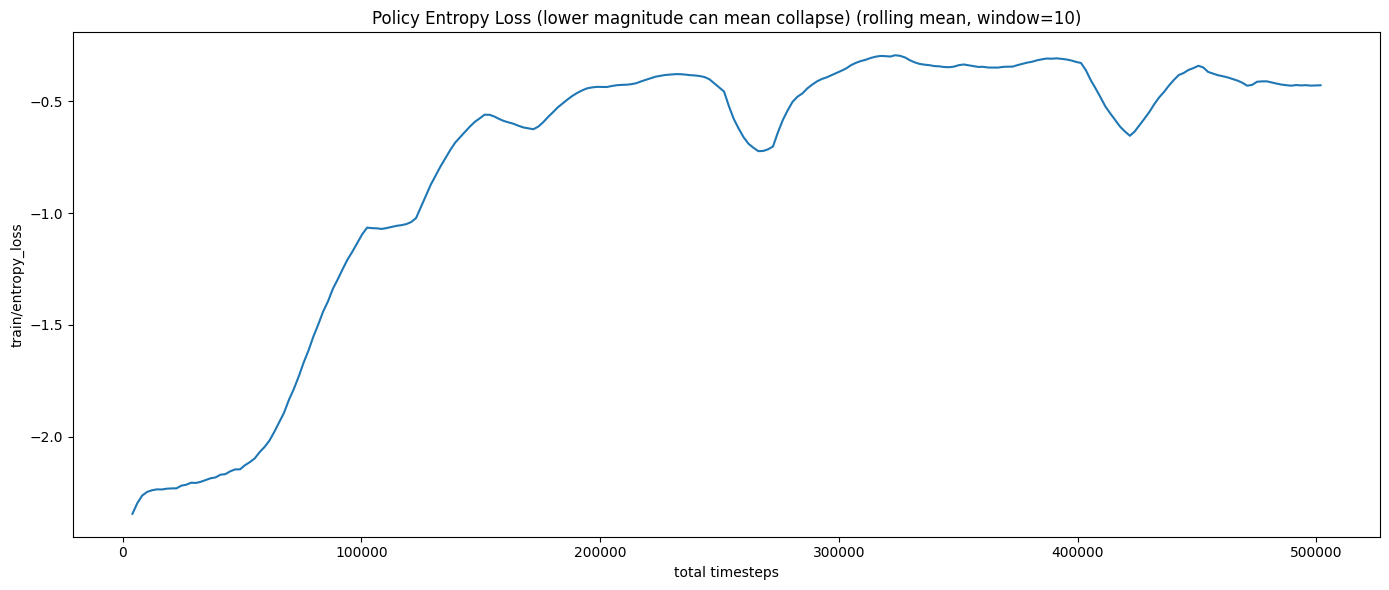

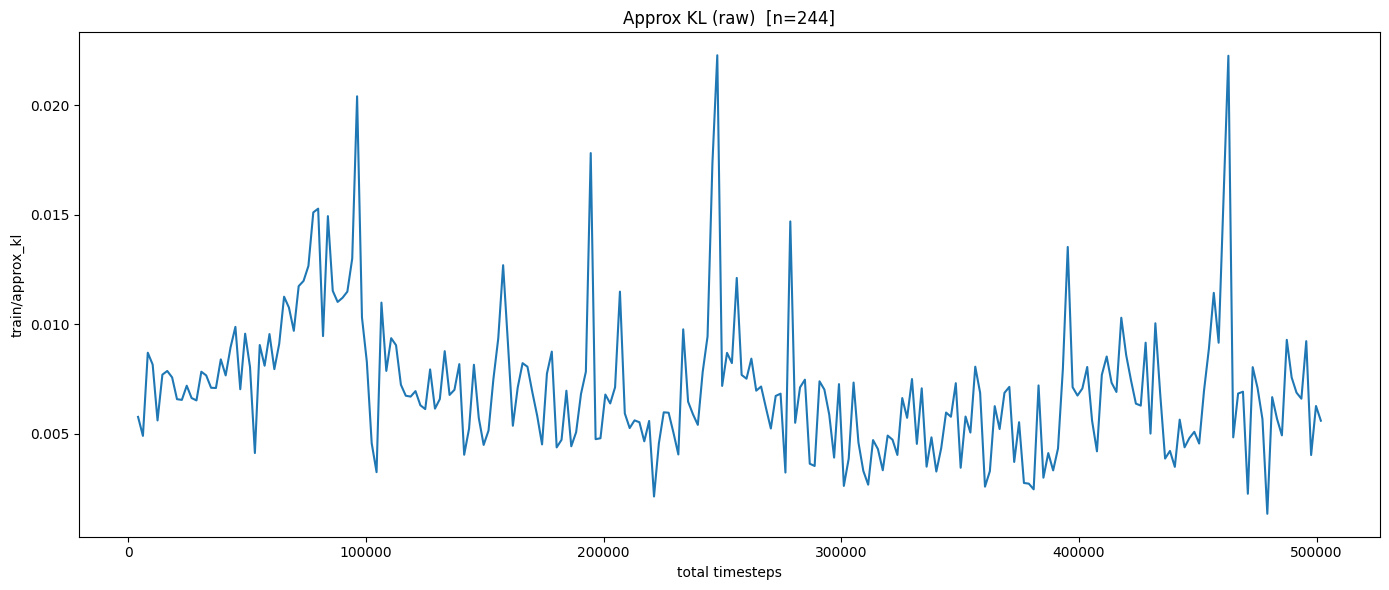

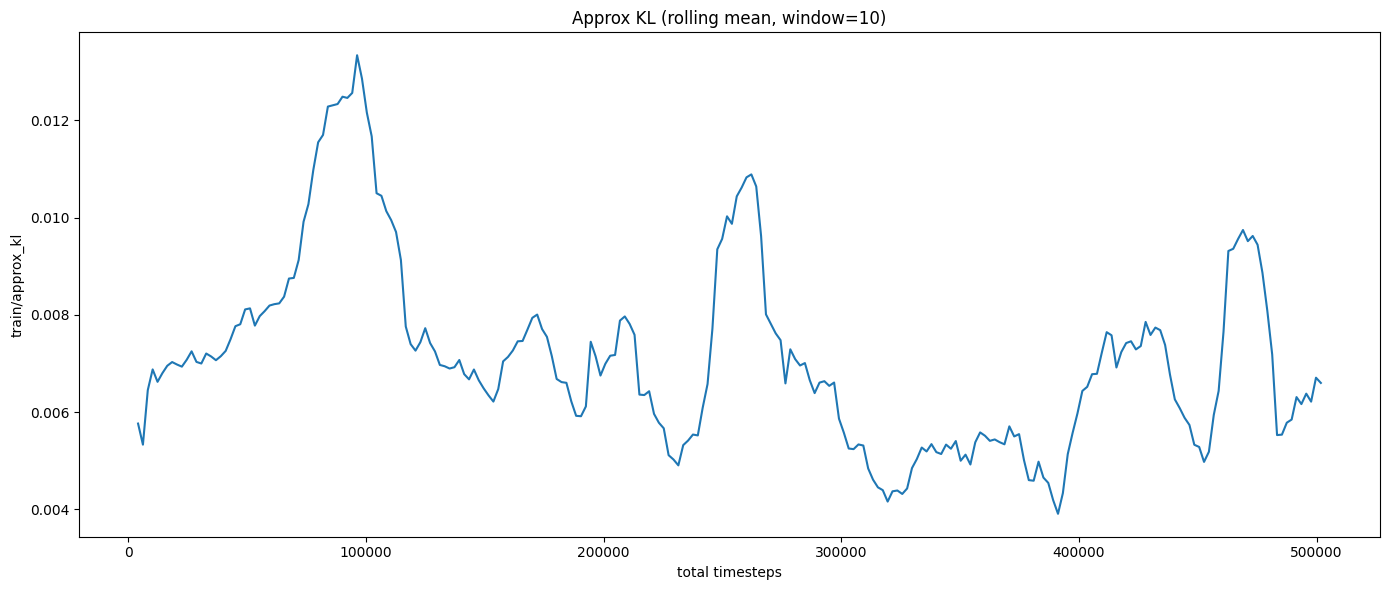

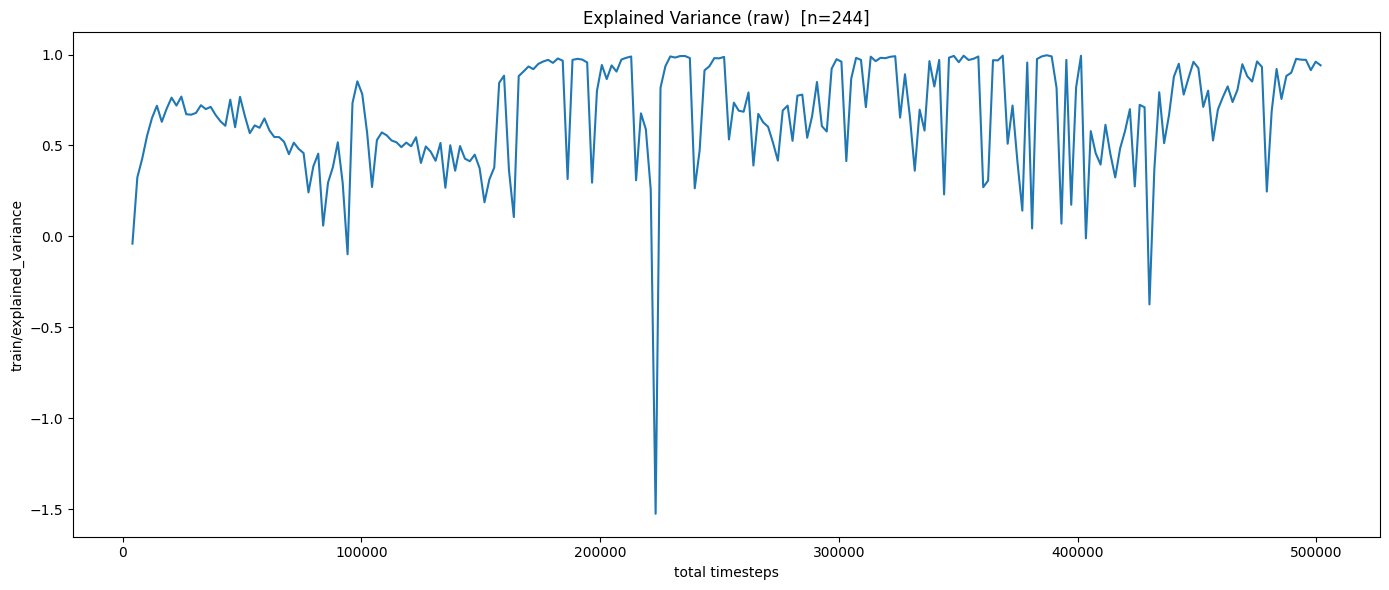

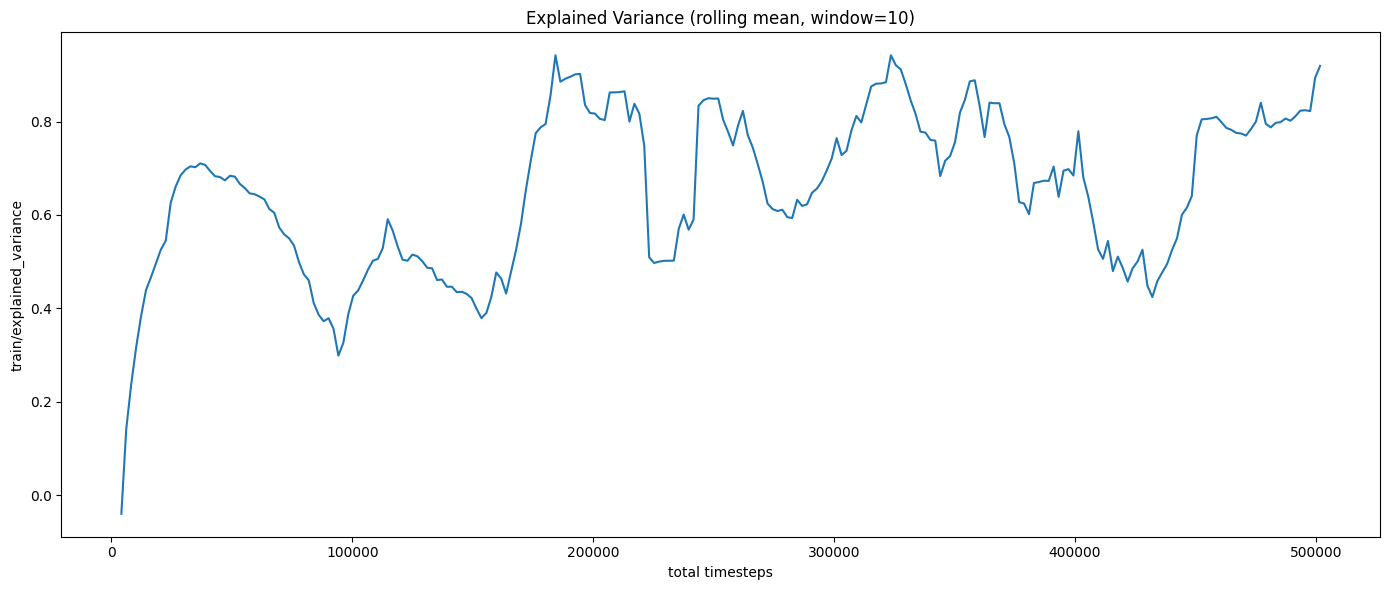

(info) moves_since_capture metric not found. If you add it, it will be plotted here.


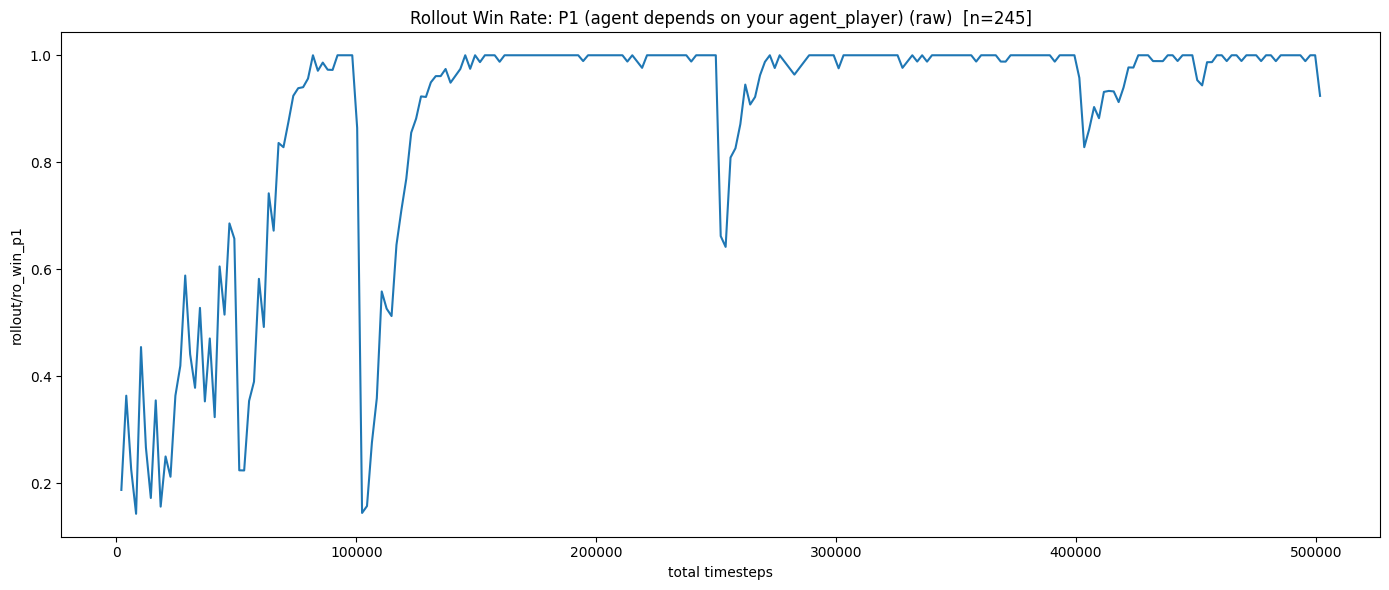

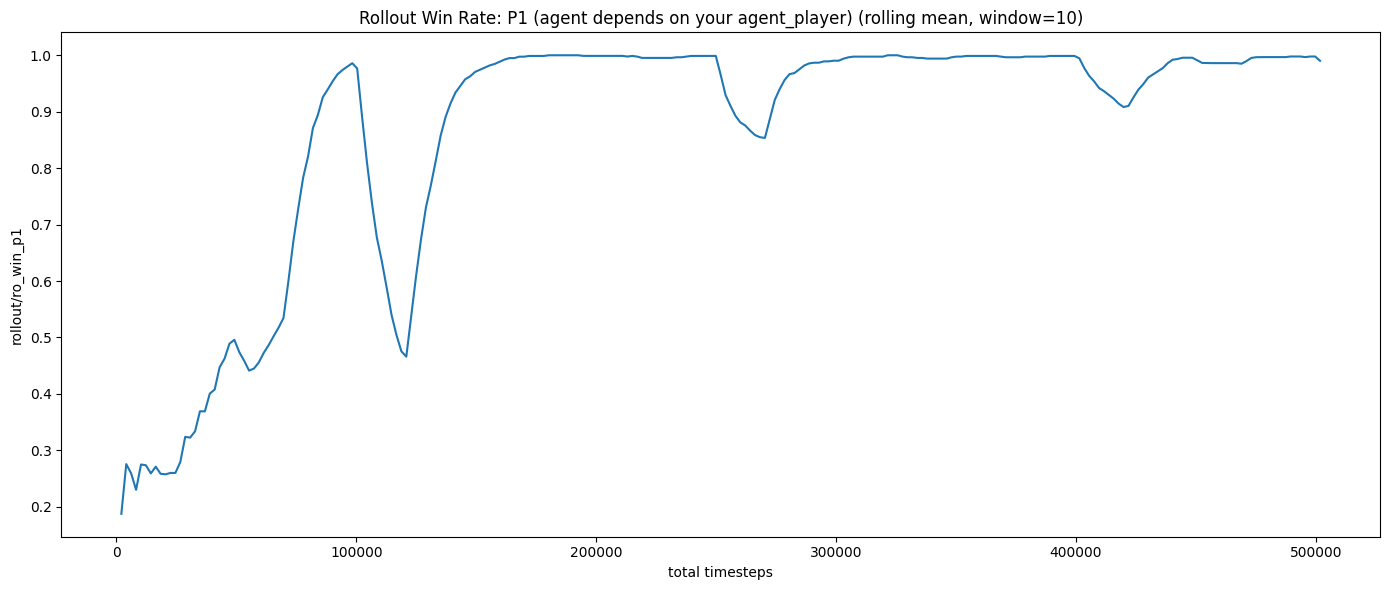

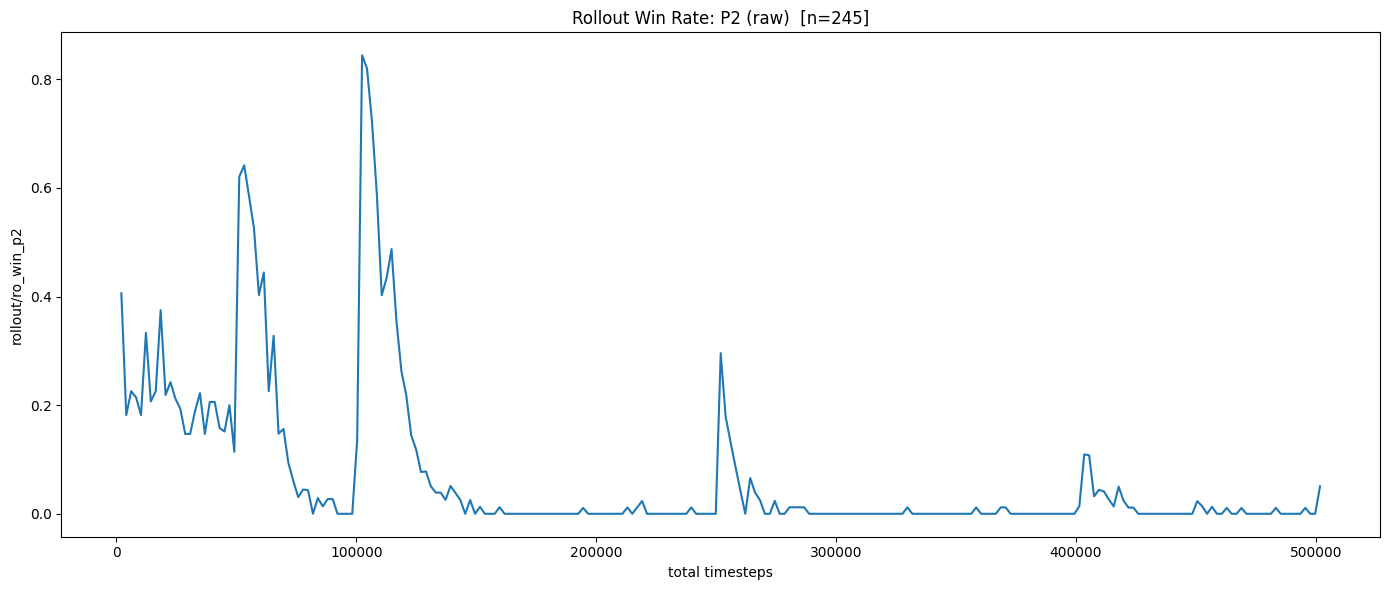

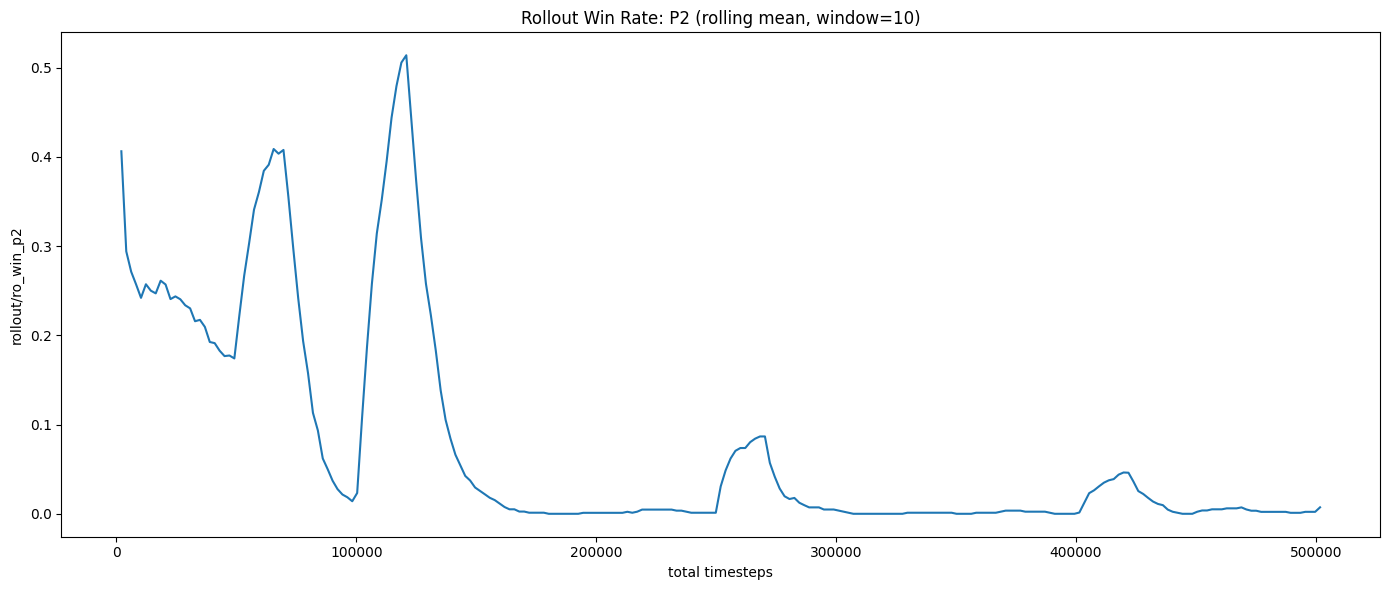

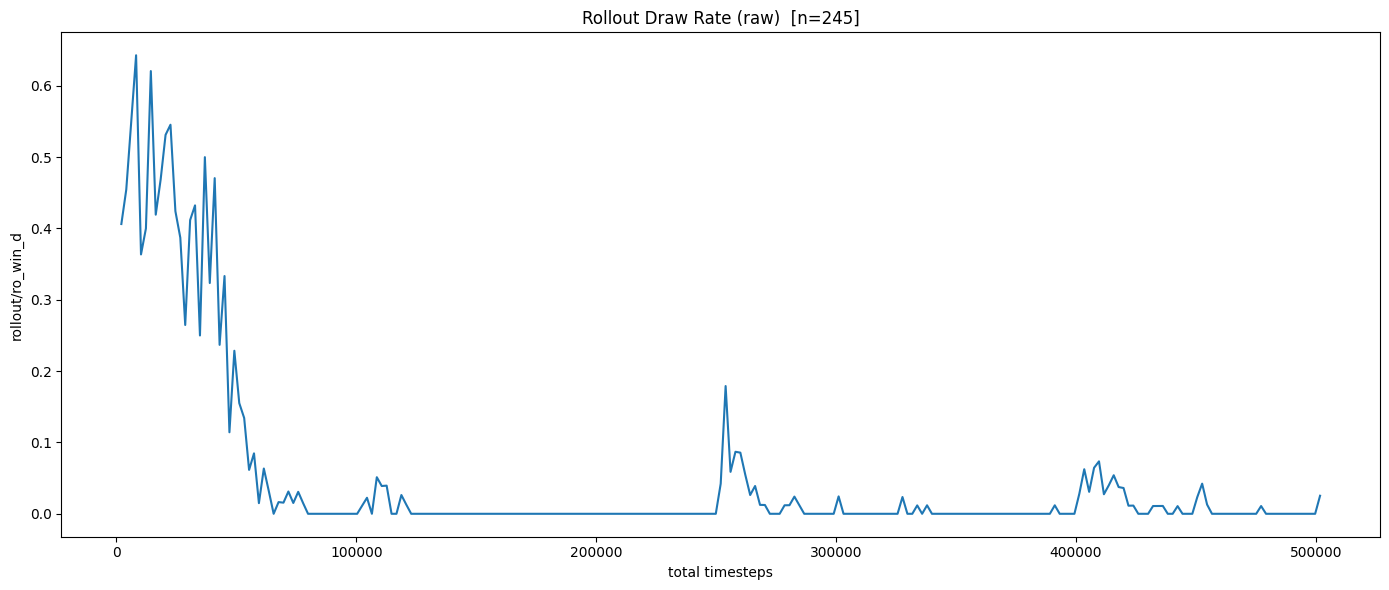

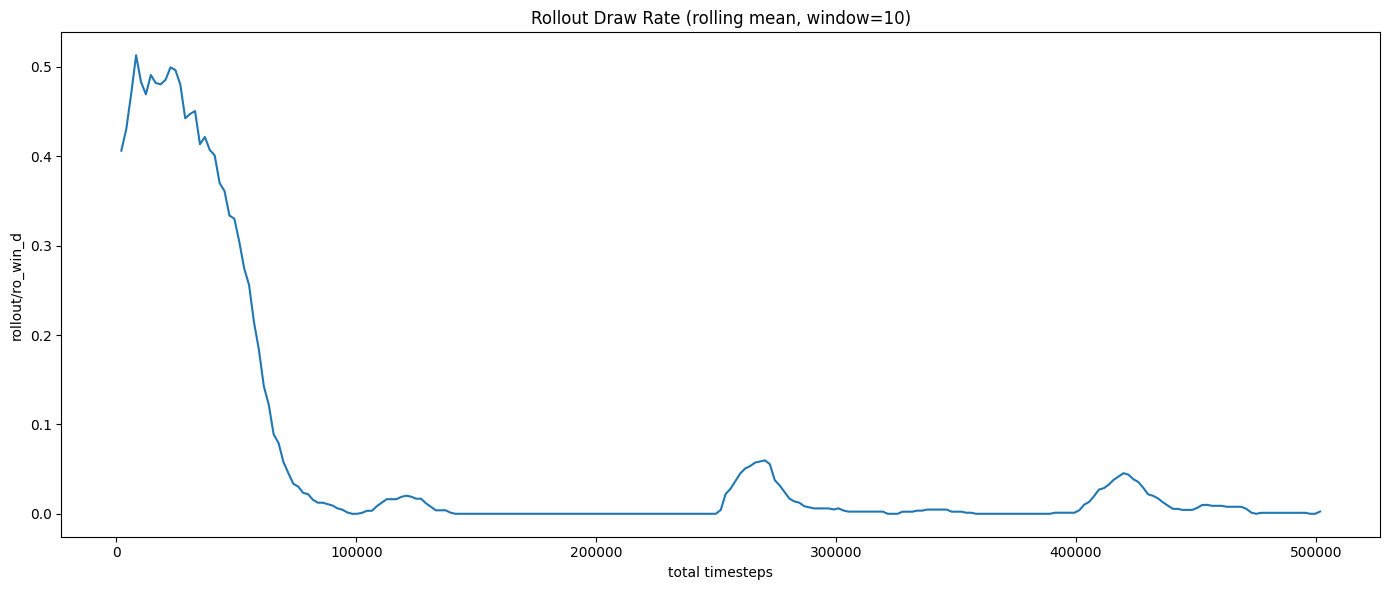

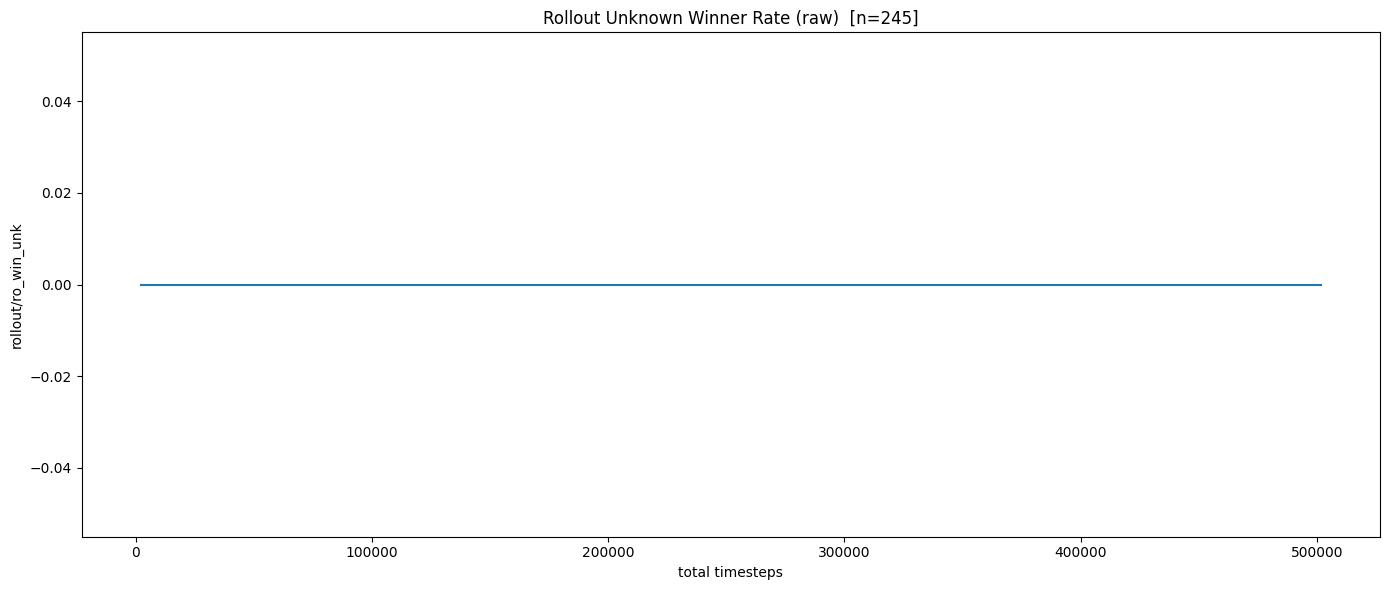

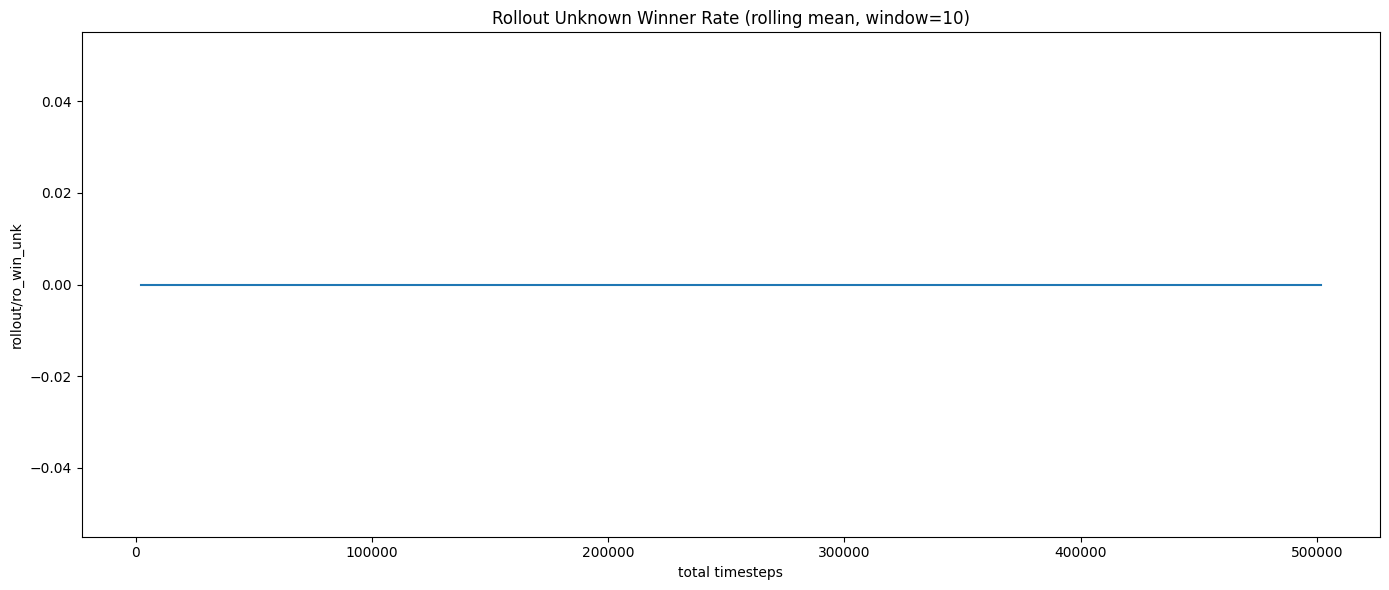

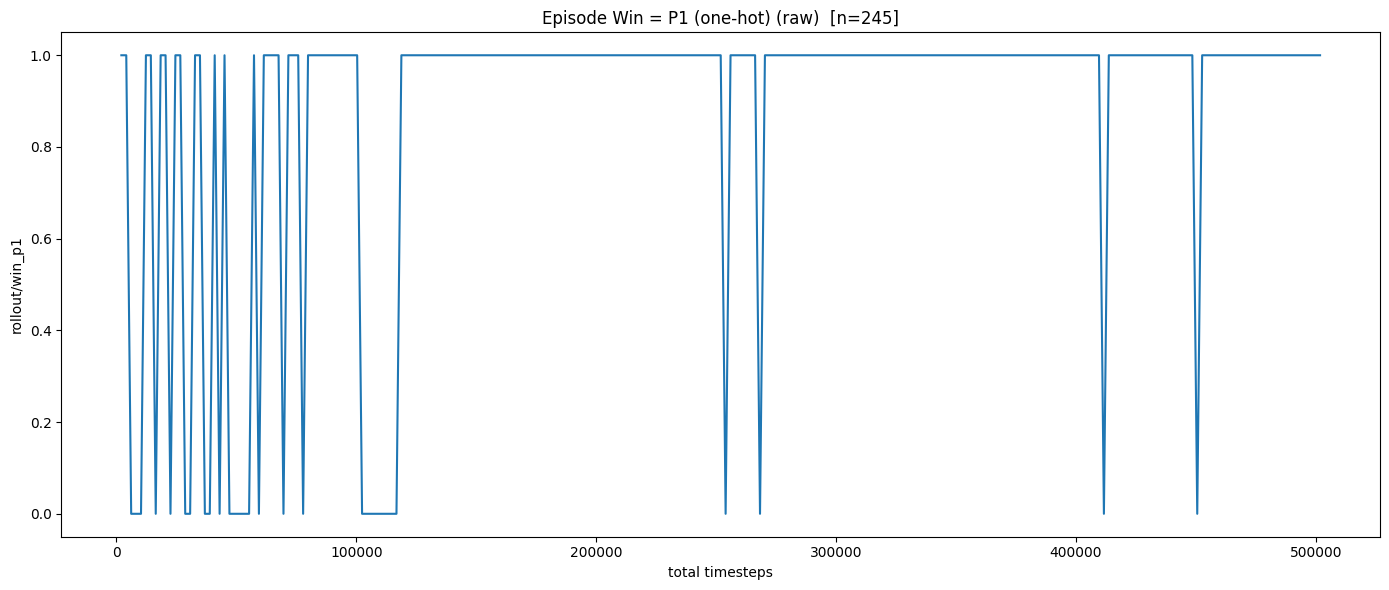

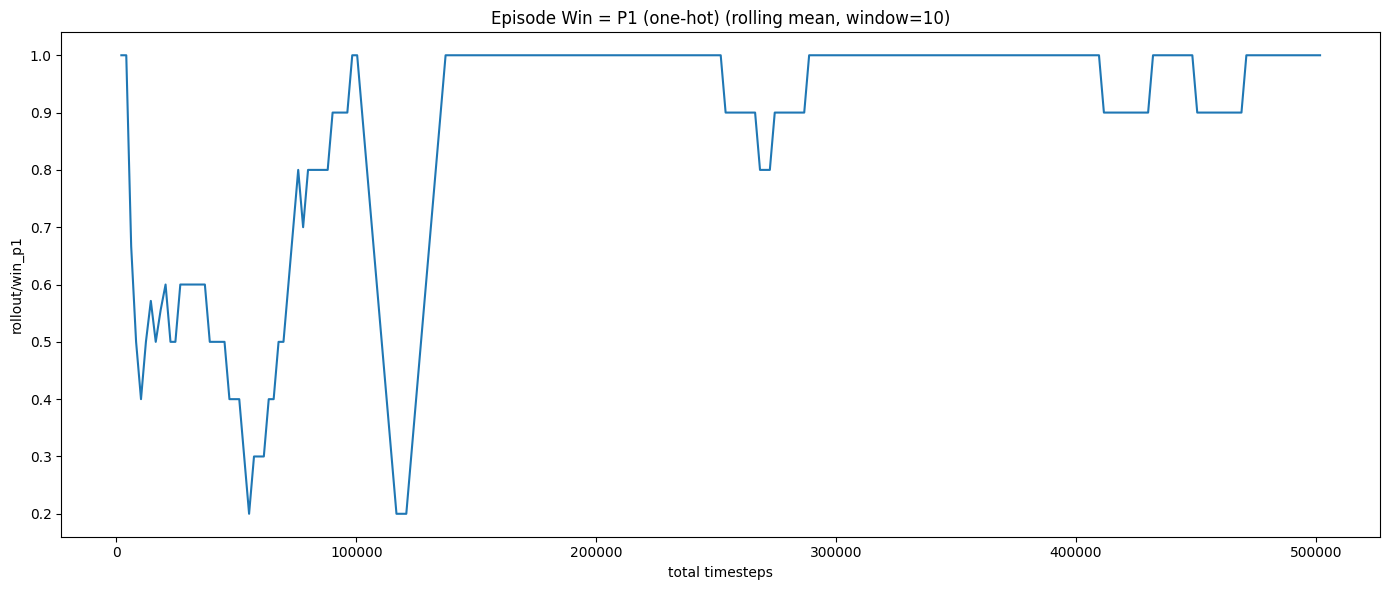

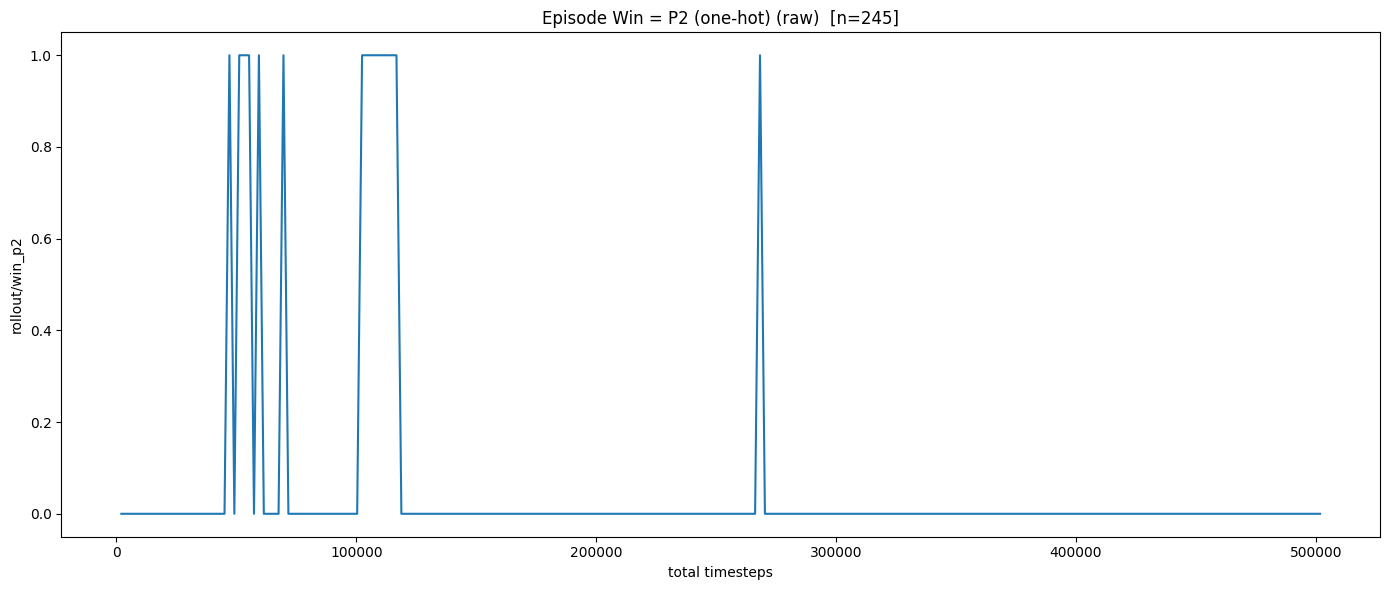

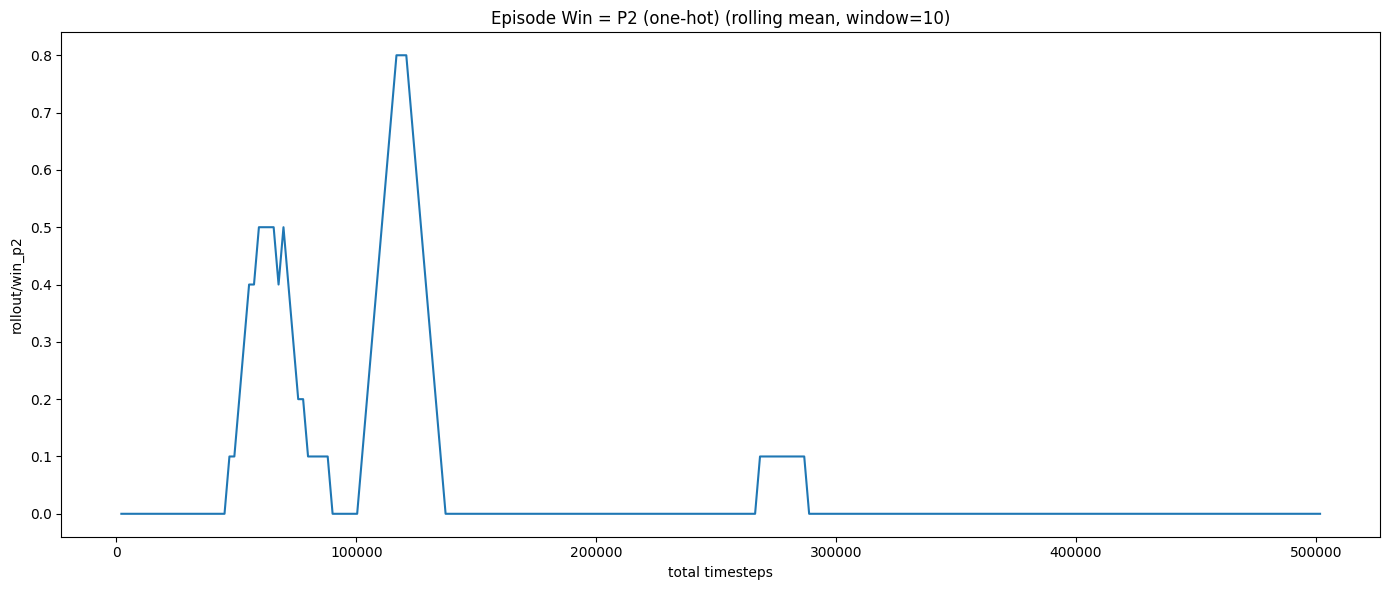

In [25]:
display(HTML("""
<style>
.jp-OutputArea-output {
    max-height: none !important;
}
.jp-OutputArea {
    max-height: none !important;
}
.jp-Cell-outputWrapper {
    max-height: none !important;
}
</style>
"""))


# Load CSV
df = pd.read_csv(csv_path)

if "time/total_timesteps" in df.columns:
    x = df["time/total_timesteps"].to_numpy()
    x_label = "total timesteps"
elif "total_timesteps" in df.columns:
    x = df["total_timesteps"].to_numpy()
    x_label = "total timesteps"
else:
    x = np.arange(len(df), dtype=float)
    x_label = "row index"


def plot_metric(col, title=None, window=20, debug=False, use_rolling=True):
    if col not in df.columns:
        print(f"Spalte fehlt: {col}")
        return

    y_all = pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)
    mask = ~np.isnan(y_all)

    n = int(mask.sum())
    if debug:
        print(f"[{col}] non-NaN points: {n}")
        if n > 0:
            show_cols = [c for c in ["time/total_timesteps", col] if c in df.columns]
            print(df.loc[mask, show_cols].head(10).to_string(index=False))

    if n < 2:
        print(f"Zu wenige Werte für {col} (non-NaN: {n})")
        return

    x_valid = x[mask]
    y = y_all[mask]
    title = title or col


    plt.figure(figsize=(14, 6))
    plt.plot(x_valid, y)
    plt.xlabel(x_label)
    plt.ylabel(col)
    plt.title(f"{title} (raw)  [n={n}]")
    plt.tight_layout()
    plt.show()

    if use_rolling:
        y_smooth = pd.Series(y).rolling(window=window, min_periods=1).mean().to_numpy()
        plt.figure(figsize=(14, 6))
        plt.plot(x_valid, y_smooth)
        plt.xlabel(x_label)
        plt.ylabel(col)
        plt.title(f"{title} (rolling mean, window={window})")
        plt.tight_layout()
        plt.show()
    else:
        if n < window:
            print(f"Hinweis: {col} hat nur {n} Punkte < window={window}, MA wäre identisch zu raw.")
            return
        kernel = np.ones(window) / window
        y_ma = np.convolve(y, kernel, mode="valid")
        x_ma = x_valid[-len(y_ma):]
        plt.figure(figsize=(14, 6))
        plt.plot(x_ma, y_ma)
        plt.xlabel(x_label)
        plt.ylabel(col)
        plt.title(f"{title} (moving average, window={window})")
        plt.tight_layout()
        plt.show()


def plot_if_exists(col, title=None, window=20, debug=False):
    if col in df.columns:
        plot_metric(col, title=title, window=window, debug=debug)
    else:
        print(f"(skip) {col} not in CSV")


# ============================================================
# 1) existing plots
# ============================================================
plot_if_exists("rollout/illegalActionRate", "Illegal Action Rate", window=10)
plot_if_exists("rollout/millsPerEpisode", "Mills per Episode", window=5, debug=True)
plot_if_exists("rollout/capturePerEpisode", "Captures per Episode", window=5)
plot_if_exists("rollout/needCaptureFrequency", "Need-Capture Frequency", window=10)
plot_if_exists("rollout/meanLegalActionCount", "Mean Legal Action Count", window=10)

# ============================================================
# 2) termination breakdown (HIGH SIGNAL)
#    These explain "why" games end (nocap vs pieces vs block vs illegal).
# ============================================================
plot_if_exists("rollout/ro_tr_nocap", "Termination Rate: No Capture (ro_tr_nocap)", window=10)
plot_if_exists("rollout/ro_tr_pieces", "Termination Rate: Pieces (ro_tr_pieces)", window=10)
plot_if_exists("rollout/ro_tr_block", "Termination Rate: Block (ro_tr_block)", window=10)
plot_if_exists("rollout/ro_tr_illeg", "Termination Rate: Illegal (ro_tr_illeg)", window=10)
plot_if_exists("rollout/ro_tr_unk", "Termination Rate: Unknown (ro_tr_unk)", window=10)
plot_if_exists("rollout/terminalReason_term_nocap", "Episode Terminal Reason = term_nocap", window=10)
plot_if_exists("rollout/terminalReason_term_pieces", "Episode Terminal Reason = term_pieces", window=10)
plot_if_exists("rollout/terminalReason_term_block", "Episode Terminal Reason = term_block", window=10)
plot_if_exists("rollout/terminalReason_term_illegal", "Episode Terminal Reason = term_illegal", window=10)
plot_if_exists("rollout/terminalReason_unknown", "Episode Terminal Reason = unknown", window=10)


# ============================================================
# 3) Episode length (helps interpret draws / nocap)
# ============================================================
plot_if_exists("rollout/ep_len_mean", "Episode Length Mean", window=10)
plot_if_exists("rollout/ep_rew_mean", "Episode Reward Mean", window=10)


# ============================================================
# 4) Policy uncertainty / collapse signal
# ============================================================
plot_if_exists("train/entropy_loss", "Policy Entropy Loss (lower magnitude can mean collapse)", window=10)
plot_if_exists("train/approx_kl", "Approx KL", window=10)
plot_if_exists("train/explained_variance", "Explained Variance", window=10)


# ============================================================
# 5) Moves since last capture (core to term_nocap)
#    Only plots if you logged it.
#    Common keys you might have used: rollout/movesSinceCaptureMean, rollout/moves_since_capture_mean, etc.
# ============================================================
for candidate in [
    "rollout/movesSinceCaptureMean",
    "rollout/moves_since_capture_mean",
    "rollout/movesSinceCapture",
    "rollout/moves_since_capture",
]:
    if candidate in df.columns:
        plot_metric(candidate, f"Moves Since Last Capture ({candidate})", window=10)
        break
else:
    print("(info) moves_since_capture metric not found. If you add it, it will be plotted here.")


# ============================================================
# 8) Winner breakdown (if logged)
# ============================================================
plot_if_exists("rollout/ro_win_p1", "Rollout Win Rate: P1 (agent depends on your agent_player)", window=10)
plot_if_exists("rollout/ro_win_p2", "Rollout Win Rate: P2", window=10)
plot_if_exists("rollout/ro_win_d", "Rollout Draw Rate", window=10)
plot_if_exists("rollout/ro_win_unk", "Rollout Unknown Winner Rate", window=10)

plot_if_exists("rollout/win_p1", "Episode Win = P1 (one-hot)", window=10)
plot_if_exists("rollout/win_p2", "Episode Win = P2 (one-hot)", window=10)


## Evaluation

In [26]:
def eval_agent(
    agent_model: MaskablePPO,
    make_env_fn, 
    opponent,      
    n_games: int = 200,
    agent_player: int = 1,      
    deterministic_agent: bool = False,
    seed: int = 42,
):
    rng = np.random.default_rng(seed)
    stats = defaultdict(list)

    for g in range(n_games):
        env = make_env_fn(
            opponent=opponent,
            agent_player=agent_player,
            seed=int(rng.integers(1_000_000_000))
        )

        obs, info = env.reset()
        done = False
        total_reward = 0.0
        ep_steps = 0

        # episode counters
        agent_mills = 0
        agent_caps = 0
        opp_mills = 0
        opp_caps = 0
        illegal_steps = 0

        while not done:
            ep_steps += 1

            mask = env.action_mask()
            action, _ = agent_model.predict(
                obs, action_masks=mask, deterministic=deterministic_agent
            )

            obs, r, term, trunc, info = env.step(int(action))
            total_reward += float(r)
            done = bool(term or trunc)

            agent_mills += int(info.get("agent_formed_mill", info.get("formed_mill", 0)))
            agent_caps  += int(info.get("agent_did_capture", info.get("did_capture", 0)))
            opp_mills   += int(info.get("opp_formed_mill", 0))
            opp_caps    += int(info.get("opp_did_capture", 0))
            illegal_steps += int(bool(info.get("illegal", False)))

        # Winner handling (robust)
        w = info.get("winner", 0)
        try:
            winner = int(w) if w is not None else 0
        except Exception:
            winner = 0

        terminal_reason = info.get("terminal_reason", "unknown")

        stats["reward"].append(total_reward)
        stats["winner"].append(winner)
        stats["terminal_reason"].append(str(terminal_reason))
        stats["agent_mills"].append(agent_mills)
        stats["agent_caps"].append(agent_caps)
        stats["opp_mills"].append(opp_mills)
        stats["opp_caps"].append(opp_caps)
        stats["illegal_steps"].append(illegal_steps)
        stats["ep_len"].append(ep_steps)

        env.close()

    winners = np.array(stats["winner"], dtype=int)

    out = {
        "n_games": int(n_games),
        "agent_player": int(agent_player),
        "win_rate": float(np.mean(winners == agent_player)),
        "loss_rate": float(np.mean(winners == -agent_player)),
        "draw_rate": float(np.mean(winners == 0)),
        "mean_reward": float(np.mean(stats["reward"])),
        "std_reward": float(np.std(stats["reward"])),
        "mean_agent_mills": float(np.mean(stats["agent_mills"])),
        "mean_agent_captures": float(np.mean(stats["agent_caps"])),
        "mean_opp_mills": float(np.mean(stats["opp_mills"])),
        "mean_opp_captures": float(np.mean(stats["opp_caps"])),
        "mean_illegal_steps": float(np.mean(stats["illegal_steps"])),
        "mean_ep_len": float(np.mean(stats["ep_len"])),
        "term_reason_counts": dict(
            (k, int(np.sum(np.array(stats["terminal_reason"]) == k)))
            for k in sorted(set(stats["terminal_reason"]))
        ),
    }
    return out


In [27]:
def _opponent_label(opponent_model):
    if opponent_model is None:
        return "random(None)"
    if callable(opponent_model) and not isinstance(opponent_model, MaskablePPO):
        return getattr(opponent_model, "__name__", opponent_model.__class__.__name__)
    if isinstance(opponent_model, MaskablePPO):
        return "MaskablePPO"
    return opponent_model.__class__.__name__

def make_eval_env(opponent_model=None, agent_player=1, seed=0, max_no_capture=50, deterministic_opp=True, opponent_id=None, eval_use_shaping=False):
    try:
        base = MillEnv(max_no_capture=max_no_capture, render_mode=None, use_shaping=eval_use_shaping)
    except TypeError:
        base = MillEnv(max_no_capture=max_no_capture, use_shaping=eval_use_shaping)

    env = FixedOpponentWrapper(
        base,
        opponent_model=None,
        agent_player=agent_player,
        deterministic_opp=deterministic_opp,
        randomize_agent_player_on_reset=False,
        rng=np.random.default_rng(seed),
    )

    label = opponent_id if opponent_id is not None else _opponent_label(opponent_model)
    env.set_opponent(opponent_model, deterministic_opp=deterministic_opp, opponent_id=label)

    return ActionMasker(env, lambda e: e.action_mask())


## Play games, both sides

In [33]:
def _opponent_label(opponent_model):
    
    if opponent_model is None:
        return "random(None)"
    cls = opponent_model.__class__.__name__
    return f"{cls}"

def _read_opponent_id_from_env(env):
    cur = env
    while True:
        if hasattr(cur, "current_opponent_id"):
            return str(cur.current_opponent_id)
        if not hasattr(cur, "env"):
            break
        cur = cur.env
    return None


def evaluate_policy(
    agent_model,
    opponent_model,
    n_games=200,
    seed=0,
    max_no_capture=50,
    eval_use_shaping=False,
    deterministic_agent=True,
    deterministic_opp=True,
    opponent_id=None,         
    debug_first_n=0,           
):
    rng = np.random.default_rng(seed)
    per_side = []


    print(f"[EVAL] opponent_model={_opponent_label(opponent_model)}  deterministic_opp={deterministic_opp}")
    if opponent_id is not None:
        print(f"[EVAL] opponent_id (requested) = {opponent_id}")


    for agent_player in (+1, -1):
        wins = losses = draws = 0
        reasons = defaultdict(int)

        agent_mills = agent_caps = 0
        opp_mills = opp_caps = 0
        illegal_steps = 0
        steps_total = 0
        rewards_total = []
        rewards_sparse = []
        rewards_shaping = []

        seen_opponent_ids = defaultdict(int)

        for g in range(n_games):
            game_seed = int(rng.integers(1_000_000_000)) # pro Episode neuer Seed
            
            env = make_eval_env(
                opponent_model=opponent_model,
                agent_player=agent_player,
                seed=game_seed, 
                max_no_capture=max_no_capture,
                deterministic_opp=deterministic_opp,
                opponent_id=opponent_id,
                eval_use_shaping=eval_use_shaping,
            )

            try:
                obs, info = env.reset(seed=game_seed)
                done = False
                ep_reward_total = 0.0
                ep_reward_sparse = 0.0
                ep_steps = 0

                opp_id = info.get("opponent_id", None) or _read_opponent_id_from_env(env) or "unknown"
                seen_opponent_ids[str(opp_id)] += 1
                
                while not done:
                    mask = get_action_masks(env)

                    action, _ = agent_model.predict(
                        obs,
                        action_masks=mask,
                        deterministic=deterministic_agent
                    )

                    obs, r, term, trunc, info = env.step(int(action))
                    done = bool(term or trunc)

                    ep_reward_total += float(r)
                    ep_reward_sparse += float(info.get("reward_sparse", r))
                    ep_steps += 1
                    steps_total += 1
                    
                    agent_mills += int(info.get("agent_formed_mill", info.get("formed_mill", 0)))
                    agent_caps  += int(info.get("agent_did_capture", info.get("did_capture", 0)))
                    opp_mills   += int(info.get("opp_formed_mill", 0))
                    opp_caps    += int(info.get("opp_did_capture", 0))
                    illegal_steps += int(info.get("illegal", 0))


                if g < debug_first_n:
                    print(
                        f"[DEBUG] agent_player={agent_player}  "
                        f"winner={info.get('winner', None)}  "
                        f"agent_player_info={info.get('agent_player', None)}  "
                        f"terminal_reason={info.get('terminal_reason', None)}"
                    )

                rewards_total.append(ep_reward_total)
                rewards_sparse.append(ep_reward_sparse)
                rewards_shaping.append(ep_reward_total - ep_reward_sparse)  # nur als Diagnose

                winner = int(info.get("winner", 0))
                ap_info = int(info.get("agent_player", agent_player))  # zur Sicherheit aus info nehmen
                tr = str(info.get("terminal_reason", "unknown"))
                reasons[tr] += 1

                if winner == ap_info:
                    wins += 1
                elif winner == -ap_info:
                    losses += 1
                else:
                    draws += 1

            finally:
                try:
                    env.close()
                except Exception:
                    pass

        per_side.append({
            "agent_player": agent_player,
            "n_games": n_games,
            "win_rate": wins / n_games,
            "loss_rate": losses / n_games,
            "draw_rate": draws / n_games,
            "mean_reward": float(np.mean(rewards_total)) if rewards_total else 0.0,
            "std_reward": float(np.std(rewards_total)) if rewards_total else 0.0,
            "mean_steps_per_game": steps_total / n_games,
            "mean_illegal_steps_per_game": illegal_steps / n_games,
            "mean_agent_mills_per_game": agent_mills / n_games,
            "mean_agent_captures_per_game": agent_caps / n_games,
            "mean_opp_mills_per_game": opp_mills / n_games,
            "mean_opp_captures_per_game": opp_caps / n_games,
            "terminal_reasons": dict(reasons),

            "seen_opponent_ids": dict(seen_opponent_ids),
            "opponent_model_label": _opponent_label(opponent_model),
            "opponent_id_requested": opponent_id,
            "deterministic_opp": bool(deterministic_opp),

            # Sparse rewards
            "mean_reward_sparse": float(np.mean(rewards_sparse)) if rewards_sparse else 0.0,
            "std_reward_sparse": float(np.std(rewards_sparse)) if rewards_sparse else 0.0,           
            "mean_reward_total": float(np.mean(rewards_total)) if rewards_total else 0.0,
            "std_reward_total": float(np.std(rewards_total)) if rewards_total else 0.0,          
            "mean_reward_shaping": float(np.mean(rewards_shaping)) if rewards_shaping else 0.0,


        })

    avg = {
        "n_games_per_side": n_games,
        "win_rate": 0.5 * (per_side[0]["win_rate"] + per_side[1]["win_rate"]),
        "loss_rate": 0.5 * (per_side[0]["loss_rate"] + per_side[1]["loss_rate"]),
        "draw_rate": 0.5 * (per_side[0]["draw_rate"] + per_side[1]["draw_rate"]),
        "mean_reward": 0.5 * (per_side[0]["mean_reward"] + per_side[1]["mean_reward"]),
        "std_reward": 0.5 * (per_side[0]["std_reward"] + per_side[1]["std_reward"]),
        "mean_steps_per_game": 0.5 * (per_side[0]["mean_steps_per_game"] + per_side[1]["mean_steps_per_game"]),
        "mean_agent_mills_per_game": 0.5 * (per_side[0]["mean_agent_mills_per_game"] + per_side[1]["mean_agent_mills_per_game"]),
        "mean_agent_captures_per_game": 0.5 * (per_side[0]["mean_agent_captures_per_game"] + per_side[1]["mean_agent_captures_per_game"]),
        "mean_opp_mills_per_game": 0.5 * (per_side[0]["mean_opp_mills_per_game"] + per_side[1]["mean_opp_mills_per_game"]),
        "mean_opp_captures_per_game": 0.5 * (per_side[0]["mean_opp_captures_per_game"] + per_side[1]["mean_opp_captures_per_game"]),

        # surface opponent info at summary level too
        "opponent_model_label": _opponent_label(opponent_model),
        "opponent_id_requested": opponent_id,
        "deterministic_opp": bool(deterministic_opp),
        "seen_opponent_ids_side_+1": per_side[0]["seen_opponent_ids"],
        "seen_opponent_ids_side_-1": per_side[1]["seen_opponent_ids"],

        # Sparse rewards
        "mean_reward_sparse": 0.5 * (per_side[0]["mean_reward_sparse"] + per_side[1]["mean_reward_sparse"]),
        "mean_reward_total": 0.5 * (per_side[0]["mean_reward_total"] + per_side[1]["mean_reward_total"]),
        "mean_reward_shaping": 0.5 * (per_side[0]["mean_reward_shaping"] + per_side[1]["mean_reward_shaping"]),

    }

    return per_side, avg


## Evaluate 2 policies: Random, Snapshot

In [34]:
def print_eval_result(title, avg, per_side):
    print("\n" + "=" * 55)
    print(f"EVALUATION — {title}")
    print("=" * 55)

    print(f"Games per side : {avg['n_games_per_side']}")

    # --- NEW: Opponent summary ---
    print()
    print("OPPONENT")
    print(f"  Model label : {avg.get('opponent_model_label', 'unknown')}")
    print(f"  Requested   : {avg.get('opponent_id_requested', 'unknown')}")
    print(f"  Deterministic opp : {avg.get('deterministic_opp', False)}")

    if "seen_opponent_ids_side_+1" in avg:
        print("  Seen opponent_ids (+1):")
        for k, v in avg["seen_opponent_ids_side_+1"].items():
            print(f"    {k:<20}: {v}")
    if "seen_opponent_ids_side_-1" in avg:
        print("  Seen opponent_ids (-1):")
        for k, v in avg["seen_opponent_ids_side_-1"].items():
            print(f"    {k:<20}: {v}")

    print()
    print("OVERALL")
    print(f"  Win rate    : {100*avg['win_rate']:.1f} %")
    print(f"  Loss rate   : {100*avg['loss_rate']:.1f} %")
    print(f"  Draw rate   : {100*avg['draw_rate']:.1f} %")
   # print(f"  Mean reward : {avg['mean_reward']:+.2f} ± {avg['std_reward']:.2f}")
   
    std_sparse = avg.get("std_reward_sparse", 0.0)
    std_total  = avg.get("std_reward_total", 0.0)

    print(f"  Mean reward (SPARSE) : {avg['mean_reward_sparse']:+.2f} ± {std_sparse:.2f}")
    print(f"  Mean reward (TOTAL)  : {avg['mean_reward_total']:+.2f} ± {std_total:.2f}")
    print(f"  Mean shaping (diag)  : {avg.get('mean_reward_shaping', 0.0):+.2f}")
    
    print(f"  Avg length  : {avg['mean_steps_per_game']:.1f} steps")
    print()

    # --- Per-side details ---
    for side in per_side:
        ap = side["agent_player"]
        print(f"AGENT ({'+1' if ap == 1 else '-1'})")

        print(
            f"  Win / Loss / Draw : "
            f"{100*side['win_rate']:.1f} % / "
            f"{100*side['loss_rate']:.1f} % / "
            f"{100*side['draw_rate']:.1f} %"
        )

        print(
            f"  Mills / Captures  : "
            f"{side['mean_agent_mills_per_game']:.2f} / "
            f"{side['mean_agent_captures_per_game']:.2f}"
        )

        print(
            f"  Opp Mills/Caps    : "
            f"{side['mean_opp_mills_per_game']:.2f} / "
            f"{side['mean_opp_captures_per_game']:.2f}"
        )

        # --- NEW: seen opponent ids per side ---
        if "seen_opponent_ids" in side:
            print("  Seen opponent_ids :")
            for k, v in side["seen_opponent_ids"].items():
                print(f"    {k:<20}: {v}")

        print("  Terminal reasons  :")
        for k, v in side["terminal_reasons"].items():
            print(f"    {k:<12}: {v}")

        print()

    print("=" * 55)


In [30]:
# Opponent A: Random
per_side, avg = evaluate_policy(
    agent_model=model,
    opponent_model=None,
    n_games=200,
    seed=0,
    deterministic_agent=True,  
    deterministic_opp=True,
    eval_use_shaping=False,
)
print_eval_result("Random Opponent", avg, per_side)

[EVAL] opponent_model=random(None)  deterministic_opp=True

EVALUATION — Random Opponent
Games per side : 200

OPPONENT
  Model label : random(None)
  Requested   : None
  Deterministic opp : True
  Seen opponent_ids (+1):
    random(None)        : 200
  Seen opponent_ids (-1):
    random(None)        : 200

OVERALL
  Win rate    : 99.2 %
  Loss rate   : 0.2 %
  Draw rate   : 0.5 %
  Mean reward (SPARSE) : +10.85 ± 0.00
  Mean reward (TOTAL)  : +10.85 ± 0.00
  Mean shaping (diag)  : +0.00
  Avg length  : 24.4 steps

AGENT (+1)
  Win / Loss / Draw : 100.0 % / 0.0 % / 0.0 %
  Mills / Captures  : 7.00 / 7.00
  Opp Mills/Caps    : 0.46 / 0.46
  Seen opponent_ids :
    random(None)        : 200
  Terminal reasons  :
    term_pieces : 200

AGENT (-1)
  Win / Loss / Draw : 98.5 % / 0.5 % / 1.0 %
  Mills / Captures  : 6.94 / 6.94
  Opp Mills/Caps    : 0.80 / 0.80
  Seen opponent_ids :
    random(None)        : 200
  Terminal reasons  :
    term_pieces : 198
    term_nocap  : 2



In [32]:
# Opponent B: Snapshot
opp_log_dir = "./logs/mill_ppo/snapshots/"
opp_csv_path = os.path.join(opp_log_dir, "snapshot_0000100000.zip")

opp = MaskablePPO.load(opp_csv_path, device="mps")
per_side, avg = evaluate_policy(
    agent_model=model,
    opponent_model=opp,
    opponent_id=opp_csv_path,
    n_games=200,
    seed=0,
    deterministic_agent=True,
    deterministic_opp=True,
    eval_use_shaping=False,
)


print_eval_result("Snapshot Opponent", avg, per_side)


[EVAL] opponent_model=MaskablePPO  deterministic_opp=True
[EVAL] opponent_id (requested) = ./logs/mill_ppo/snapshots/snapshot_0000100000.zip

EVALUATION — Snapshot Opponent
Games per side : 200

OPPONENT
  Model label : MaskablePPO
  Requested   : ./logs/mill_ppo/snapshots/snapshot_0000100000.zip
  Deterministic opp : True
  Seen opponent_ids (+1):
    ./logs/mill_ppo/snapshots/snapshot_0000100000.zip: 200
  Seen opponent_ids (-1):
    ./logs/mill_ppo/snapshots/snapshot_0000100000.zip: 200

OVERALL
  Win rate    : 100.0 %
  Loss rate   : 0.0 %
  Draw rate   : 0.0 %
  Mean reward (SPARSE) : +10.83 ± 0.00
  Mean reward (TOTAL)  : +10.83 ± 0.00
  Mean shaping (diag)  : +0.00
  Avg length  : 25.0 steps

AGENT (+1)
  Win / Loss / Draw : 100.0 % / 0.0 % / 0.0 %
  Mills / Captures  : 7.00 / 7.00
  Opp Mills/Caps    : 1.00 / 1.00
  Seen opponent_ids :
    ./logs/mill_ppo/snapshots/snapshot_0000100000.zip: 200
  Terminal reasons  :
    term_pieces : 200

AGENT (-1)
  Win / Loss / Draw : 100.0 %

## Compare "sparse reward" model with "potential-based reward" shaping model

In [45]:
path_sparse = os.path.join(log_dir, "maskable_selfplay_mill_sparse.zip")
path_pbrs   = os.path.join(log_dir, "maskable_selfplay_mill_pbrs.zip")

model_sparse = MaskablePPO.load(path_sparse, device=device)  # oder "mps"/"cuda"
model_pbrs   = MaskablePPO.load(path_pbrs,   device=device)


In [46]:
per_side, avg = evaluate_policy(
    agent_model=model_pbrs,
    opponent_model=model_sparse,
    opponent_id="sparse",          # nur Label in deiner Ausgabe
    n_games=200,
    seed=0,
    deterministic_agent=True,
    deterministic_opp=True,
    eval_use_shaping=False,        # FAIR: immer False
)
print_eval_result("PBRS (agent) vs Sparse (opponent)", avg, per_side)


[EVAL] opponent_model=MaskablePPO  deterministic_opp=True
[EVAL] opponent_id (requested) = sparse

EVALUATION — PBRS (agent) vs Sparse (opponent)
Games per side : 200

OPPONENT
  Model label : MaskablePPO
  Requested   : sparse
  Deterministic opp : True
  Seen opponent_ids (+1):
    sparse              : 200
  Seen opponent_ids (-1):
    sparse              : 200

OVERALL
  Win rate    : 50.0 %
  Loss rate   : 0.0 %
  Draw rate   : 50.0 %
  Mean reward (SPARSE) : +5.30 ± 0.00
  Mean reward (TOTAL)  : +5.30 ± 0.00
  Mean shaping (diag)  : +0.00
  Avg length  : 37.5 steps

AGENT (+1)
  Win / Loss / Draw : 0.0 % / 0.0 % / 100.0 %
  Mills / Captures  : 6.00 / 6.00
  Opp Mills/Caps    : 4.00 / 4.00
  Seen opponent_ids :
    sparse              : 200
  Terminal reasons  :
    term_nocap  : 200

AGENT (-1)
  Win / Loss / Draw : 100.0 % / 0.0 % / 0.0 %
  Mills / Captures  : 7.00 / 7.00
  Opp Mills/Caps    : 5.00 / 5.00
  Seen opponent_ids :
    sparse              : 200
  Terminal reasons  :


In [47]:
per_side, avg = evaluate_policy(
    agent_model=model_sparse,
    opponent_model=model_pbrs,
    opponent_id="pbrs",
    n_games=200,
    seed=1,                        # anderer Seed ok
    deterministic_agent=True,
    deterministic_opp=True,
    eval_use_shaping=False,
)
print_eval_result("Sparse (agent) vs PBRS (opponent)", avg, per_side)


[EVAL] opponent_model=MaskablePPO  deterministic_opp=True
[EVAL] opponent_id (requested) = pbrs

EVALUATION — Sparse (agent) vs PBRS (opponent)
Games per side : 200

OPPONENT
  Model label : MaskablePPO
  Requested   : pbrs
  Deterministic opp : True
  Seen opponent_ids (+1):
    pbrs                : 200
  Seen opponent_ids (-1):
    pbrs                : 200

OVERALL
  Win rate    : 0.0 %
  Loss rate   : 50.0 %
  Draw rate   : 50.0 %
  Mean reward (SPARSE) : -5.30 ± 0.00
  Mean reward (TOTAL)  : -5.30 ± 0.00
  Mean shaping (diag)  : +0.00
  Avg length  : 35.0 steps

AGENT (+1)
  Win / Loss / Draw : 0.0 % / 100.0 % / 0.0 %
  Mills / Captures  : 5.00 / 5.00
  Opp Mills/Caps    : 7.00 / 7.00
  Seen opponent_ids :
    pbrs                : 200
  Terminal reasons  :
    term_pieces : 200

AGENT (-1)
  Win / Loss / Draw : 0.0 % / 0.0 % / 100.0 %
  Mills / Captures  : 4.00 / 4.00
  Opp Mills/Caps    : 6.00 / 6.00
  Seen opponent_ids :
    pbrs                : 200
  Terminal reasons  :
    